## COL Phyloseq analysis

*see DR_phyloseq.ipnyb for information on conda and package installation*

starting with ASV table from steps: 1. Kraken2 (PlusPF db), 2. Bracken filtering, 3. normalized by number of sequences

In [2]:
#load libraries
library(tidyverse)
library(vegan)
library(phyloseq)
library(ggplot2)
library(RColorBrewer)
library(DESeq2)
library(dplyr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following obj

In [3]:
getwd()

[1] "/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL"

In [4]:
setwd("/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/kraken_bracken")

In [5]:
taxa = read.csv('all_otu_id_species.csv',header=TRUE)
head(taxa)

,taxonomy_id,name,taxonomy_lvl
,<int>,<chr>,<chr>
1,2066072,Bacterioplanoides sp.,S
2,562,Escherichia coli,S
3,28213,Sphingomonas parapaucimobilis,S
4,2562892,Myroides albus,S
5,4779,Bremia lactucae,S
6,2093777,Podospora bellae-mahoneyi,S


In [6]:
# remove taxa level col
taxa$taxonomy_lvl <- NULL 
# change taxa table names
colnames(taxa) <- c("otuid","species")

In [7]:
head(taxa)

,otuid,species
,<int>,<chr>
1,2066072,Bacterioplanoides sp.
2,562,Escherichia coli
3,28213,Sphingomonas parapaucimobilis
4,2562892,Myroides albus
5,4779,Bremia lactucae
6,2093777,Podospora bellae-mahoneyi


In [8]:
# make the index the otu ids
row.names(taxa) <- taxa$otuid
taxa$otuid <- NULL
head(taxa)

,species
,<chr>
2066072,Bacterioplanoides sp.
562,Escherichia coli
28213,Sphingomonas parapaucimobilis
2562892,Myroides albus
4779,Bremia lactucae
2093777,Podospora bellae-mahoneyi


In [9]:
#convert to character matrix to create phyloseq objects 
taxonomy <- as.matrix(taxa)

# check structure
str(taxonomy) 

 chr [1:13441, 1] "Bacterioplanoides sp." "Escherichia coli" ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:13441] "2066072" "562" "28213" "2562892" ...
  ..$ : chr "species"


In [26]:
#read in normalized otu table
otu = read.csv('all_otu_normtable_species.csv',header=TRUE)
head(otu)

,X,X012025_COL_SAN_T5_568_OFAV_S1,X012025_COL_SAN_T5_569_DLAB_S2,X012025_COL_SAN_T5_571_DLAB_S4,X012025_COL_SAN_T5_572_OFAV_S5,X012025_COL_SAN_T5_573_PSTR_S6,X012025_COL_SAN_T5_574_MCAV_S7,X012025_COL_SAN_T5_575_DLAB_S8,X012025_COL_SAN_T5_576_PSTR_S9,X012025_COL_SAN_T5_577_PSTR_S10,⋯,X032024_COL_SAN_T5_154_PSTR_S38,X032024_COL_SAN_T5_158_DLAB_S15,X032024_COL_SAN_T5_159_DLAB_S16,X032024_COL_SAN_T5_160_DLAB_S41,X032024_COL_SAN_T5_161_DLAB_S42,X032024_COL_SAN_T5_162_PSTR_S39,X032024_COL_SAN_T5_163_PSTR_S11c,X032024_COL_SAN_T5_166_OFAV_S20,X032024_COL_SAN_T5_167_OFAV_S21,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2066072,34004.255,34629.54441,21306.6544,33729.125,24268.2520,56344.5236,10949.1077,55155.85514,53933.69619,⋯,42358.4913,56429.6985,59799.0673,37805.2917,22399.1963,28720.5286,60705.4611,31327.225,37307.529,2224938.12
2,562,16079.761,4034.90895,75158.5746,15530.492,3723.0474,7127.8399,5949.8478,3710.79662,3369.82134,⋯,6174.8789,5336.1676,4768.9063,5173.7901,13252.1984,3418.3194,4012.5199,15042.343,14923.012,552305.15
3,28213,13945.658,168.46361,567.9852,11060.559,255.7245,18874.1946,4611.8548,31.94614,77.25573,⋯,0.0000,0.0000,0.0000,0.0000,157.3262,0.0000,4439.2762,0.000,0.000,289710.30
4,2562892,9953.668,1372.36211,1069.6575,11437.926,1600.5343,1322.4822,700.7984,1114.75222,1907.48075,⋯,3019.5696,1453.6583,1979.1488,1621.0005,708.4277,2409.8718,1502.4854,14098.292,13199.204,218889.60
5,4779,9562.361,669.74558,418.0602,8432.281,651.3453,1207.1889,444.0703,1143.33561,2669.00151,⋯,1357.3977,1775.0701,1747.5462,1058.7442,817.9120,868.3051,1223.4524,7045.675,9468.451,145593.62
6,2093777,9503.172,57.52416,144.1587,7409.140,133.8793,149.2031,160.7442,361.49582,820.38227,⋯,256.1128,452.8986,214.0569,166.3557,137.0854,193.5988,772.7068,6469.527,10484.415,96283.33


In [27]:
# rename first col as otu
names(otu)[1] <- "otu"
head(otu)
dim(otu)

,otu,X012025_COL_SAN_T5_568_OFAV_S1,X012025_COL_SAN_T5_569_DLAB_S2,X012025_COL_SAN_T5_571_DLAB_S4,X012025_COL_SAN_T5_572_OFAV_S5,X012025_COL_SAN_T5_573_PSTR_S6,X012025_COL_SAN_T5_574_MCAV_S7,X012025_COL_SAN_T5_575_DLAB_S8,X012025_COL_SAN_T5_576_PSTR_S9,X012025_COL_SAN_T5_577_PSTR_S10,⋯,X032024_COL_SAN_T5_154_PSTR_S38,X032024_COL_SAN_T5_158_DLAB_S15,X032024_COL_SAN_T5_159_DLAB_S16,X032024_COL_SAN_T5_160_DLAB_S41,X032024_COL_SAN_T5_161_DLAB_S42,X032024_COL_SAN_T5_162_PSTR_S39,X032024_COL_SAN_T5_163_PSTR_S11c,X032024_COL_SAN_T5_166_OFAV_S20,X032024_COL_SAN_T5_167_OFAV_S21,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2066072,34004.255,34629.54441,21306.6544,33729.125,24268.2520,56344.5236,10949.1077,55155.85514,53933.69619,⋯,42358.4913,56429.6985,59799.0673,37805.2917,22399.1963,28720.5286,60705.4611,31327.225,37307.529,2224938.12
2,562,16079.761,4034.90895,75158.5746,15530.492,3723.0474,7127.8399,5949.8478,3710.79662,3369.82134,⋯,6174.8789,5336.1676,4768.9063,5173.7901,13252.1984,3418.3194,4012.5199,15042.343,14923.012,552305.15
3,28213,13945.658,168.46361,567.9852,11060.559,255.7245,18874.1946,4611.8548,31.94614,77.25573,⋯,0.0000,0.0000,0.0000,0.0000,157.3262,0.0000,4439.2762,0.000,0.000,289710.30
4,2562892,9953.668,1372.36211,1069.6575,11437.926,1600.5343,1322.4822,700.7984,1114.75222,1907.48075,⋯,3019.5696,1453.6583,1979.1488,1621.0005,708.4277,2409.8718,1502.4854,14098.292,13199.204,218889.60
5,4779,9562.361,669.74558,418.0602,8432.281,651.3453,1207.1889,444.0703,1143.33561,2669.00151,⋯,1357.3977,1775.0701,1747.5462,1058.7442,817.9120,868.3051,1223.4524,7045.675,9468.451,145593.62
6,2093777,9503.172,57.52416,144.1587,7409.140,133.8793,149.2031,160.7442,361.49582,820.38227,⋯,256.1128,452.8986,214.0569,166.3557,137.0854,193.5988,772.7068,6469.527,10484.415,96283.33


[1] 13442    57

In [28]:
#remove X's from headers
names(otu) <- sub("^X", "", names(otu))
otu_table=as.data.frame(otu)
head(otu_table)

,otu,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,⋯,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2066072,34004.255,34629.54441,21306.6544,33729.125,24268.2520,56344.5236,10949.1077,55155.85514,53933.69619,⋯,42358.4913,56429.6985,59799.0673,37805.2917,22399.1963,28720.5286,60705.4611,31327.225,37307.529,2224938.12
2,562,16079.761,4034.90895,75158.5746,15530.492,3723.0474,7127.8399,5949.8478,3710.79662,3369.82134,⋯,6174.8789,5336.1676,4768.9063,5173.7901,13252.1984,3418.3194,4012.5199,15042.343,14923.012,552305.15
3,28213,13945.658,168.46361,567.9852,11060.559,255.7245,18874.1946,4611.8548,31.94614,77.25573,⋯,0.0000,0.0000,0.0000,0.0000,157.3262,0.0000,4439.2762,0.000,0.000,289710.30
4,2562892,9953.668,1372.36211,1069.6575,11437.926,1600.5343,1322.4822,700.7984,1114.75222,1907.48075,⋯,3019.5696,1453.6583,1979.1488,1621.0005,708.4277,2409.8718,1502.4854,14098.292,13199.204,218889.60
5,4779,9562.361,669.74558,418.0602,8432.281,651.3453,1207.1889,444.0703,1143.33561,2669.00151,⋯,1357.3977,1775.0701,1747.5462,1058.7442,817.9120,868.3051,1223.4524,7045.675,9468.451,145593.62
6,2093777,9503.172,57.52416,144.1587,7409.140,133.8793,149.2031,160.7442,361.49582,820.38227,⋯,256.1128,452.8986,214.0569,166.3557,137.0854,193.5988,772.7068,6469.527,10484.415,96283.33


In [29]:
# make the index the otus
row.names(otu_table) <- otu_table$otu
otu_table$otu <- NULL
head(otu_table)

,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_578_MCAV_S11,⋯,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,Sum
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2066072,34004.255,34629.54441,21306.6544,33729.125,24268.2520,56344.5236,10949.1077,55155.85514,53933.69619,45617.3886,⋯,42358.4913,56429.6985,59799.0673,37805.2917,22399.1963,28720.5286,60705.4611,31327.225,37307.529,2224938.12
562,16079.761,4034.90895,75158.5746,15530.492,3723.0474,7127.8399,5949.8478,3710.79662,3369.82134,4886.9333,⋯,6174.8789,5336.1676,4768.9063,5173.7901,13252.1984,3418.3194,4012.5199,15042.343,14923.012,552305.15
28213,13945.658,168.46361,567.9852,11060.559,255.7245,18874.1946,4611.8548,31.94614,77.25573,19042.8103,⋯,0.0000,0.0000,0.0000,0.0000,157.3262,0.0000,4439.2762,0.000,0.000,289710.30
2562892,9953.668,1372.36211,1069.6575,11437.926,1600.5343,1322.4822,700.7984,1114.75222,1907.48075,1725.1536,⋯,3019.5696,1453.6583,1979.1488,1621.0005,708.4277,2409.8718,1502.4854,14098.292,13199.204,218889.60
4779,9562.361,669.74558,418.0602,8432.281,651.3453,1207.1889,444.0703,1143.33561,2669.00151,1130.0658,⋯,1357.3977,1775.0701,1747.5462,1058.7442,817.9120,868.3051,1223.4524,7045.675,9468.451,145593.62
2093777,9503.172,57.52416,144.1587,7409.140,133.8793,149.2031,160.7442,361.49582,820.38227,108.1978,⋯,256.1128,452.8986,214.0569,166.3557,137.0854,193.5988,772.7068,6469.527,10484.415,96283.33


In [30]:
#remove Sum column
otu_table$Sum <- NULL
head(otu_table)

,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_578_MCAV_S11,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2066072,34004.255,34629.54441,21306.6544,33729.125,24268.2520,56344.5236,10949.1077,55155.85514,53933.69619,45617.3886,⋯,16563.47603,42358.4913,56429.6985,59799.0673,37805.2917,22399.1963,28720.5286,60705.4611,31327.225,37307.529
562,16079.761,4034.90895,75158.5746,15530.492,3723.0474,7127.8399,5949.8478,3710.79662,3369.82134,4886.9333,⋯,5276.83092,6174.8789,5336.1676,4768.9063,5173.7901,13252.1984,3418.3194,4012.5199,15042.343,14923.012
28213,13945.658,168.46361,567.9852,11060.559,255.7245,18874.1946,4611.8548,31.94614,77.25573,19042.8103,⋯,77.83893,0.0000,0.0000,0.0000,0.0000,157.3262,0.0000,4439.2762,0.000,0.000
2562892,9953.668,1372.36211,1069.6575,11437.926,1600.5343,1322.4822,700.7984,1114.75222,1907.48075,1725.1536,⋯,1200.01687,3019.5696,1453.6583,1979.1488,1621.0005,708.4277,2409.8718,1502.4854,14098.292,13199.204
4779,9562.361,669.74558,418.0602,8432.281,651.3453,1207.1889,444.0703,1143.33561,2669.00151,1130.0658,⋯,515.68292,1357.3977,1775.0701,1747.5462,1058.7442,817.9120,868.3051,1223.4524,7045.675,9468.451
2093777,9503.172,57.52416,144.1587,7409.140,133.8793,149.2031,160.7442,361.49582,820.38227,108.1978,⋯,61.62249,256.1128,452.8986,214.0569,166.3557,137.0854,193.5988,772.7068,6469.527,10484.415


In [31]:
# sort by most abundant OTUs
otus_sorted <- otu_table[order(rowSums(otu_table), decreasing = TRUE), ]
head(otus_sorted)

,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_578_MCAV_S11,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Total_reads,304109.000,243376.0000,346840.0000,376292.000,664778.0000,147450.000,864728.000,594751.00000,543649.00000,166362.000,⋯,308329.00000,390453.000,273792.000,284971.000,775447.000,1086914.0000,692153.000,792021.000,144060.000,120083.000
2066072,34004.255,34629.5444,21306.6544,33729.125,24268.2520,56344.524,10949.108,55155.85514,53933.69619,45617.389,⋯,16563.47603,42358.491,56429.698,59799.067,37805.292,22399.1963,28720.529,60705.461,31327.225,37307.529
588596,9016.504,5012.8197,3087.8791,8461.514,3736.5857,17300.780,2685.237,9630.92118,7922.39110,15682.668,⋯,8374.17175,5219.578,9109.105,8920.206,5871.452,4598.3399,5267.621,8150.036,8586.700,9618.347
562,16079.761,4034.9089,75158.5746,15530.492,3723.0474,7127.840,5949.848,3710.79662,3369.82134,4886.933,⋯,5276.83092,6174.879,5336.168,4768.906,5173.790,13252.1984,3418.319,4012.520,15042.343,14923.012
2057741,3235.682,373.9070,429.5929,2662.826,1177.8368,4367.582,1691.861,127.78457,222.57008,6648.153,⋯,4219.51876,33330.516,3962.862,2947.668,26347.384,16679.3325,76208.584,3746.113,3526.308,4205.425
28213,13945.658,168.4636,567.9852,11060.559,255.7245,18874.195,4611.855,31.94614,77.25573,19042.810,⋯,77.83893,0.000,0.000,0.000,0.000,157.3262,0.000,4439.276,0.000,0.000


In [32]:
#remove total reads row
otus_sorted <- otus_sorted[-1, ]
head(otus_sorted)
dim (otus_sorted)

,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_578_MCAV_S11,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2066072,34004.255,34629.5444,21306.6544,33729.125,24268.2520,56344.524,10949.108,55155.85514,53933.69619,45617.389,⋯,16563.47603,42358.491,56429.698,59799.067,37805.292,22399.1963,28720.529,60705.461,31327.225,37307.529
588596,9016.504,5012.8197,3087.8791,8461.514,3736.5857,17300.780,2685.237,9630.92118,7922.39110,15682.668,⋯,8374.17175,5219.578,9109.105,8920.206,5871.452,4598.3399,5267.621,8150.036,8586.700,9618.347
562,16079.761,4034.9089,75158.5746,15530.492,3723.0474,7127.840,5949.848,3710.79662,3369.82134,4886.933,⋯,5276.83092,6174.879,5336.168,4768.906,5173.790,13252.1984,3418.319,4012.520,15042.343,14923.012
2057741,3235.682,373.9070,429.5929,2662.826,1177.8368,4367.582,1691.861,127.78457,222.57008,6648.153,⋯,4219.51876,33330.516,3962.862,2947.668,26347.384,16679.3325,76208.584,3746.113,3526.308,4205.425
28213,13945.658,168.4636,567.9852,11060.559,255.7245,18874.195,4611.855,31.94614,77.25573,19042.810,⋯,77.83893,0.000,0.000,0.000,0.000,157.3262,0.000,4439.276,0.000,0.000
573,4577.306,1968.1481,2566.0247,3428.189,1887.8483,4971.177,3684.396,2313.57324,2816.15528,5962.900,⋯,12678.01602,1831.206,1990.562,2400.244,1724.167,2722.3865,1989.445,3797.879,7351.104,5471.216


[1] 13441    55

In [33]:
# Convert to matrix
otus=as.matrix(otus_sorted)
head(otus)

,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_578_MCAV_S11,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
2066072,34004.255,34629.5444,21306.6544,33729.125,24268.2520,56344.524,10949.108,55155.85514,53933.69619,45617.389,⋯,16563.47603,42358.491,56429.698,59799.067,37805.292,22399.1963,28720.529,60705.461,31327.225,37307.529
588596,9016.504,5012.8197,3087.8791,8461.514,3736.5857,17300.780,2685.237,9630.92118,7922.39110,15682.668,⋯,8374.17175,5219.578,9109.105,8920.206,5871.452,4598.3399,5267.621,8150.036,8586.700,9618.347
562,16079.761,4034.9089,75158.5746,15530.492,3723.0474,7127.840,5949.848,3710.79662,3369.82134,4886.933,⋯,5276.83092,6174.879,5336.168,4768.906,5173.790,13252.1984,3418.319,4012.520,15042.343,14923.012
2057741,3235.682,373.9070,429.5929,2662.826,1177.8368,4367.582,1691.861,127.78457,222.57008,6648.153,⋯,4219.51876,33330.516,3962.862,2947.668,26347.384,16679.3325,76208.584,3746.113,3526.308,4205.425
28213,13945.658,168.4636,567.9852,11060.559,255.7245,18874.195,4611.855,31.94614,77.25573,19042.810,⋯,77.83893,0.000,0.000,0.000,0.000,157.3262,0.000,4439.276,0.000,0.000
573,4577.306,1968.1481,2566.0247,3428.189,1887.8483,4971.177,3684.396,2313.57324,2816.15528,5962.900,⋯,12678.01602,1831.206,1990.562,2400.244,1724.167,2722.3865,1989.445,3797.879,7351.104,5471.216


metadata! \
Realized an issue with tag number 82 (both PSTR and DLAB had this tag). for now removing DLAB 82. The inital sample back in 032024 was a PSTR and we have that colony sampled and sequenced for both 032024 and 012025. **So removing 012025_COL_SAN_T5_570_DLAB from analysis for now.** Removed from sample list, metadata, and normalized otu table.

In [46]:
#read in metadata
metadata=read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/kraken_bracken/COL_metadata_012025.csv', header=TRUE)
head(metadata)

,SampleID,Transect,CollectionDate,Year,Tag,Species,Health_status_sampled,X032026_status,Antibiotic_Treatment,Probiotic_Experiment_Date,Probiotic_Treatment
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,012025_COL_SAN_T5_568_OFAV_S1,ELARBOL,1/17/25,Jan-2025,37,OFAV,Healthy,Healthy,Y-2025,,
2,012025_COL_SAN_T5_569_DLAB_S2,ELARBOL,1/17/25,Jan-2025,94,DLAB,Healthy,Healthy,,,
3,012025_COL_SAN_T5_571_DLAB_S4,ELARBOL,1/17/25,Jan-2025,88,DLAB,Healthy,Healthy,,,
4,012025_COL_SAN_T5_572_OFAV_S5,ELARBOL,1/17/25,Jan-2025,28,OFAV,Healthy,Healthy,Y-2025,Y-2026,Healthy_Treatment
5,012025_COL_SAN_T5_573_PSTR_S6,ELARBOL,1/17/25,Jan-2025,96,PSTR,Healthy,Healthy,,,
6,012025_COL_SAN_T5_574_MCAV_S7,ELARBOL,1/17/25,Jan-2025,14,MCAV,Healthy,Diseased,,,


In [47]:
# index the SampleIDs
row.names(metadata) <- metadata$SampleID
metadata$SampleID <- NULL
head(metadata)

,Transect,CollectionDate,Year,Tag,Species,Health_status_sampled,X032026_status,Antibiotic_Treatment,Probiotic_Experiment_Date,Probiotic_Treatment
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
012025_COL_SAN_T5_568_OFAV_S1,ELARBOL,1/17/25,Jan-2025,37,OFAV,Healthy,Healthy,Y-2025,,
012025_COL_SAN_T5_569_DLAB_S2,ELARBOL,1/17/25,Jan-2025,94,DLAB,Healthy,Healthy,,,
012025_COL_SAN_T5_571_DLAB_S4,ELARBOL,1/17/25,Jan-2025,88,DLAB,Healthy,Healthy,,,
012025_COL_SAN_T5_572_OFAV_S5,ELARBOL,1/17/25,Jan-2025,28,OFAV,Healthy,Healthy,Y-2025,Y-2026,Healthy_Treatment
012025_COL_SAN_T5_573_PSTR_S6,ELARBOL,1/17/25,Jan-2025,96,PSTR,Healthy,Healthy,,,
012025_COL_SAN_T5_574_MCAV_S7,ELARBOL,1/17/25,Jan-2025,14,MCAV,Healthy,Diseased,,,


In [34]:
# classify phyloseq objects 
OTU=otu_table((otus), taxa_are_rows = TRUE)

In [23]:
TAX=tax_table(taxonomy)

In [48]:
SAMP=sample_data(metadata)

In [49]:
# Create phyloseq object
COL_all = phyloseq(OTU, SAMP, TAX)
COL_all

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 13441 taxa and 55 samples ]
sample_data() Sample Data:       [ 55 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 13441 taxa by 1 taxonomic ranks ]

In [50]:
COL_all.ord <- ordinate(COL_all, "NMDS", "bray", trymax=1000)

Square root transformation


Warning message in decostand(x, "max", 2, na.rm = na.rm):
“result contains NaN, perhaps due to impossible mathematical
                 operation
”
Warning message in decostand(x, "total", 1, na.rm = na.rm):
“result contains NaN, perhaps due to impossible mathematical
                 operation
”


Wisconsin double standardization
Run 0 stress 0.08608714 
Run 1 stress 0.08842711 
Run 2 stress 0.09509431 
Run 3 stress 0.09643785 
Run 4 stress 0.09648847 
Run 5 stress 0.09618017 
Run 6 stress 0.08613574 
... Procrustes: rmse 0.001838413  max resid 0.01242285 
Run 7 stress 0.08833211 
Run 8 stress 0.08842711 
Run 9 stress 0.08842711 
Run 10 stress 0.09643785 
Run 11 stress 0.09617857 
Run 12 stress 0.09511083 
Run 13 stress 0.09624982 
Run 14 stress 0.09624982 
Run 15 stress 0.09620257 
Run 16 stress 0.08833822 
Run 17 stress 0.09509793 
Run 18 stress 0.08614218 
... Procrustes: rmse 0.001896469  max resid 0.01237933 
Run 19 stress 0.09908432 
Run 20 stress 0.1076309 
Run 21 stress 0.09509793 
Run 22 stress 0.08842711 
Run 23 stress 0.08608714 
... New best solution
... Procrustes: rmse 1.670963e-06  max resid 9.164575e-06 
... Similar to previous best
*** Best solution repeated 1 times


Warning message in metaMDS(veganifyOTU(physeq), distance, ...):
“WA scores were not calculated due to missing values”


In [51]:
options(repr.plot.width=20, repr.plot.height=15)

In [52]:
library(RColorBrewer)

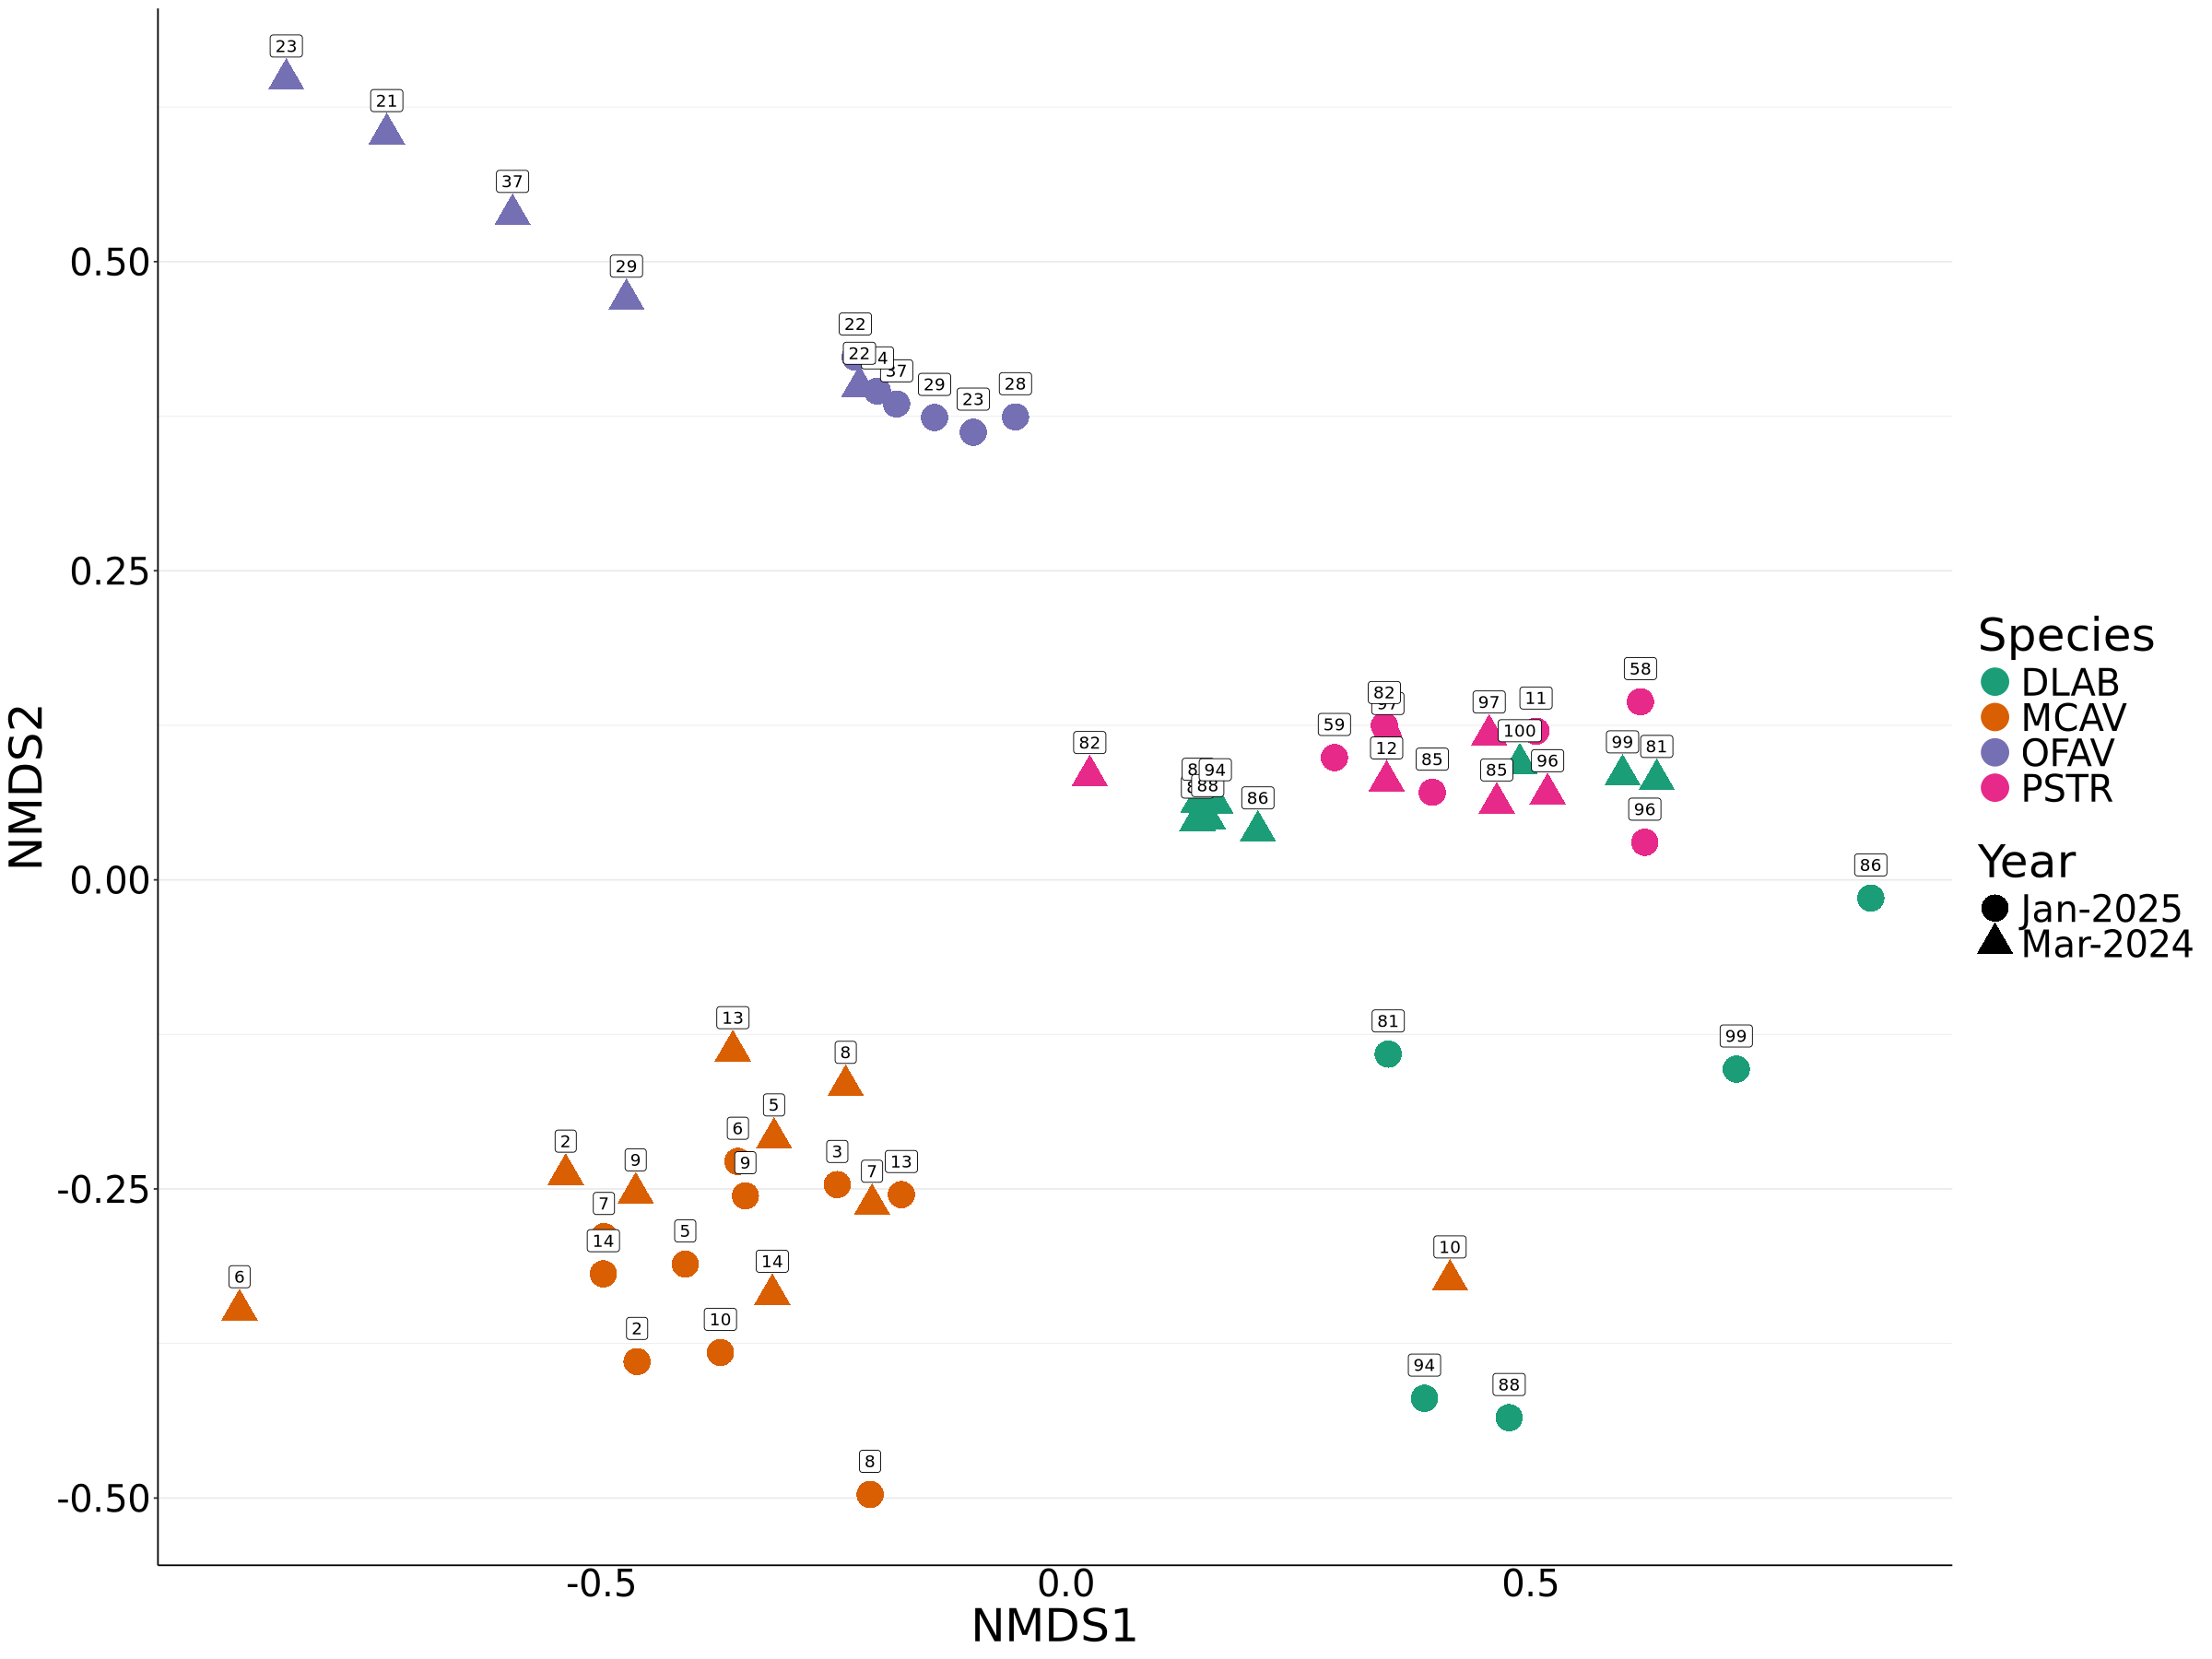

In [54]:
# visualize ordination plot

COL_all_plot <- plot_ordination(COL_all, COL_all.ord, type="Samples", color="Species", shape="Year")+
geom_point(size=8) + scale_color_brewer(palette = "Dark2")+
geom_label(aes(label = SAMP$Tag), vjust = -1, color = "black") +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 30))
COL_all_plot

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


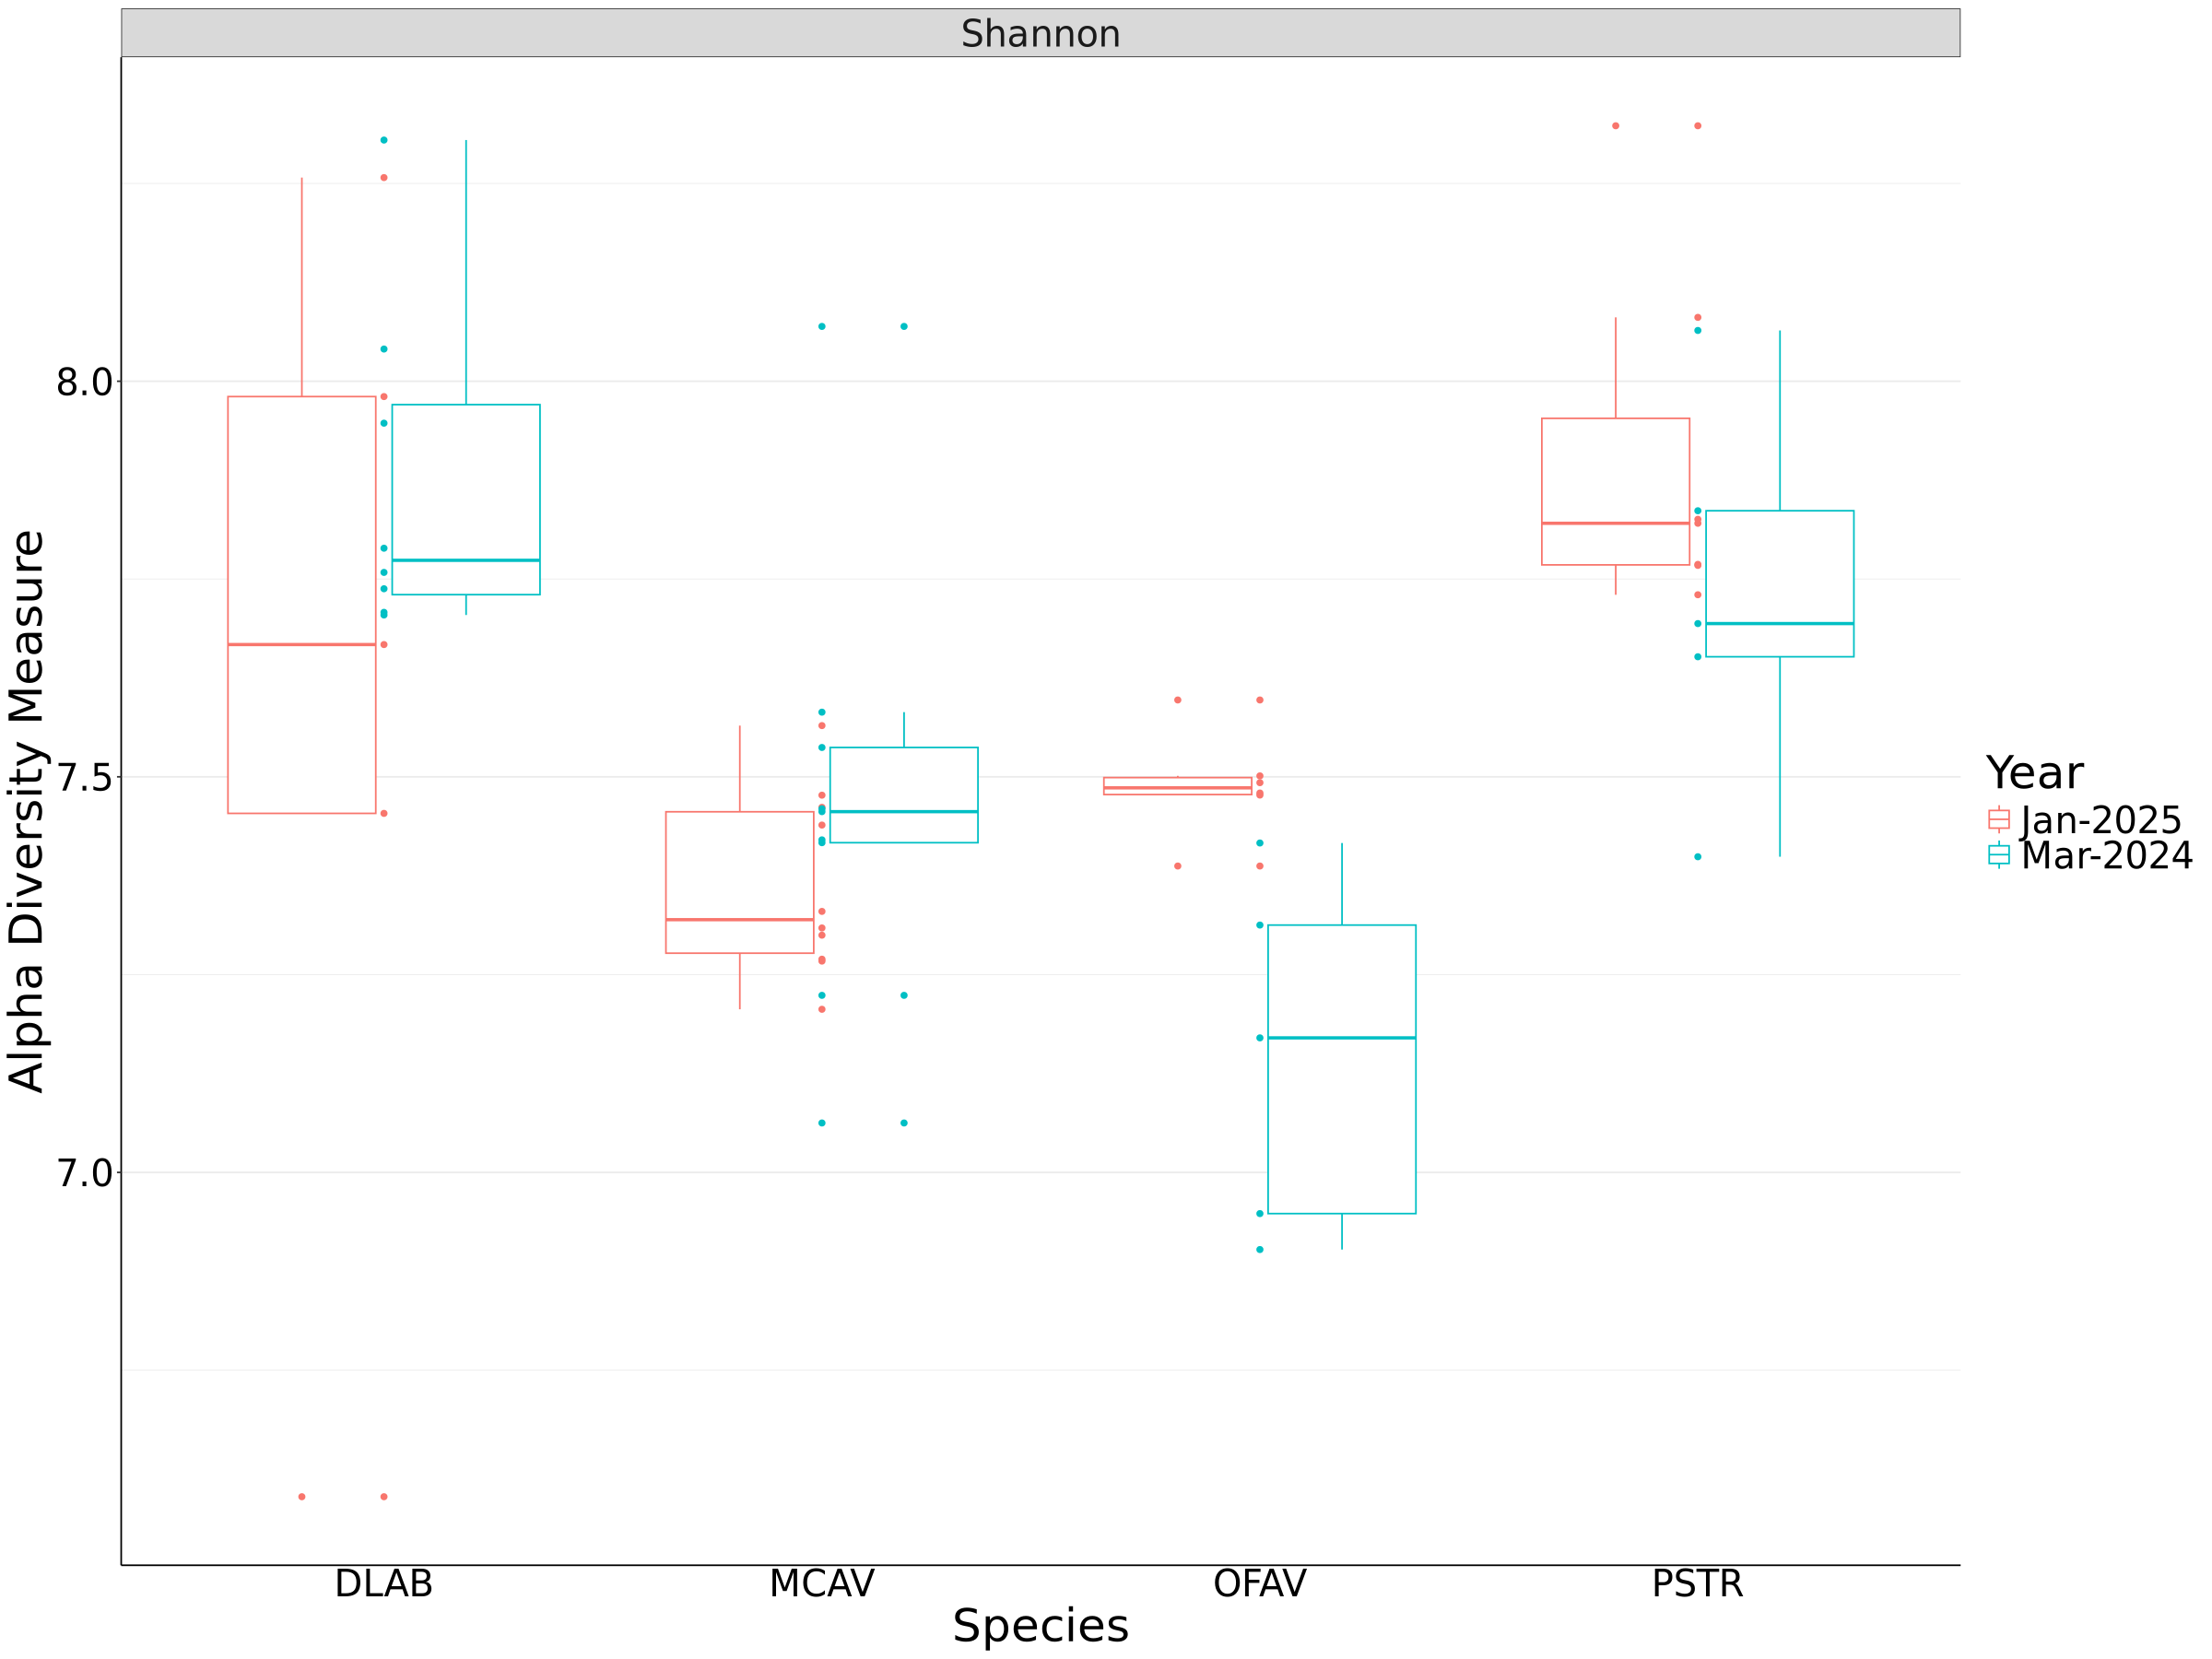

In [77]:
plot_richness(COL_all, x="Species", color="Year", measures=c("Shannon")) + geom_boxplot() +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 30))

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


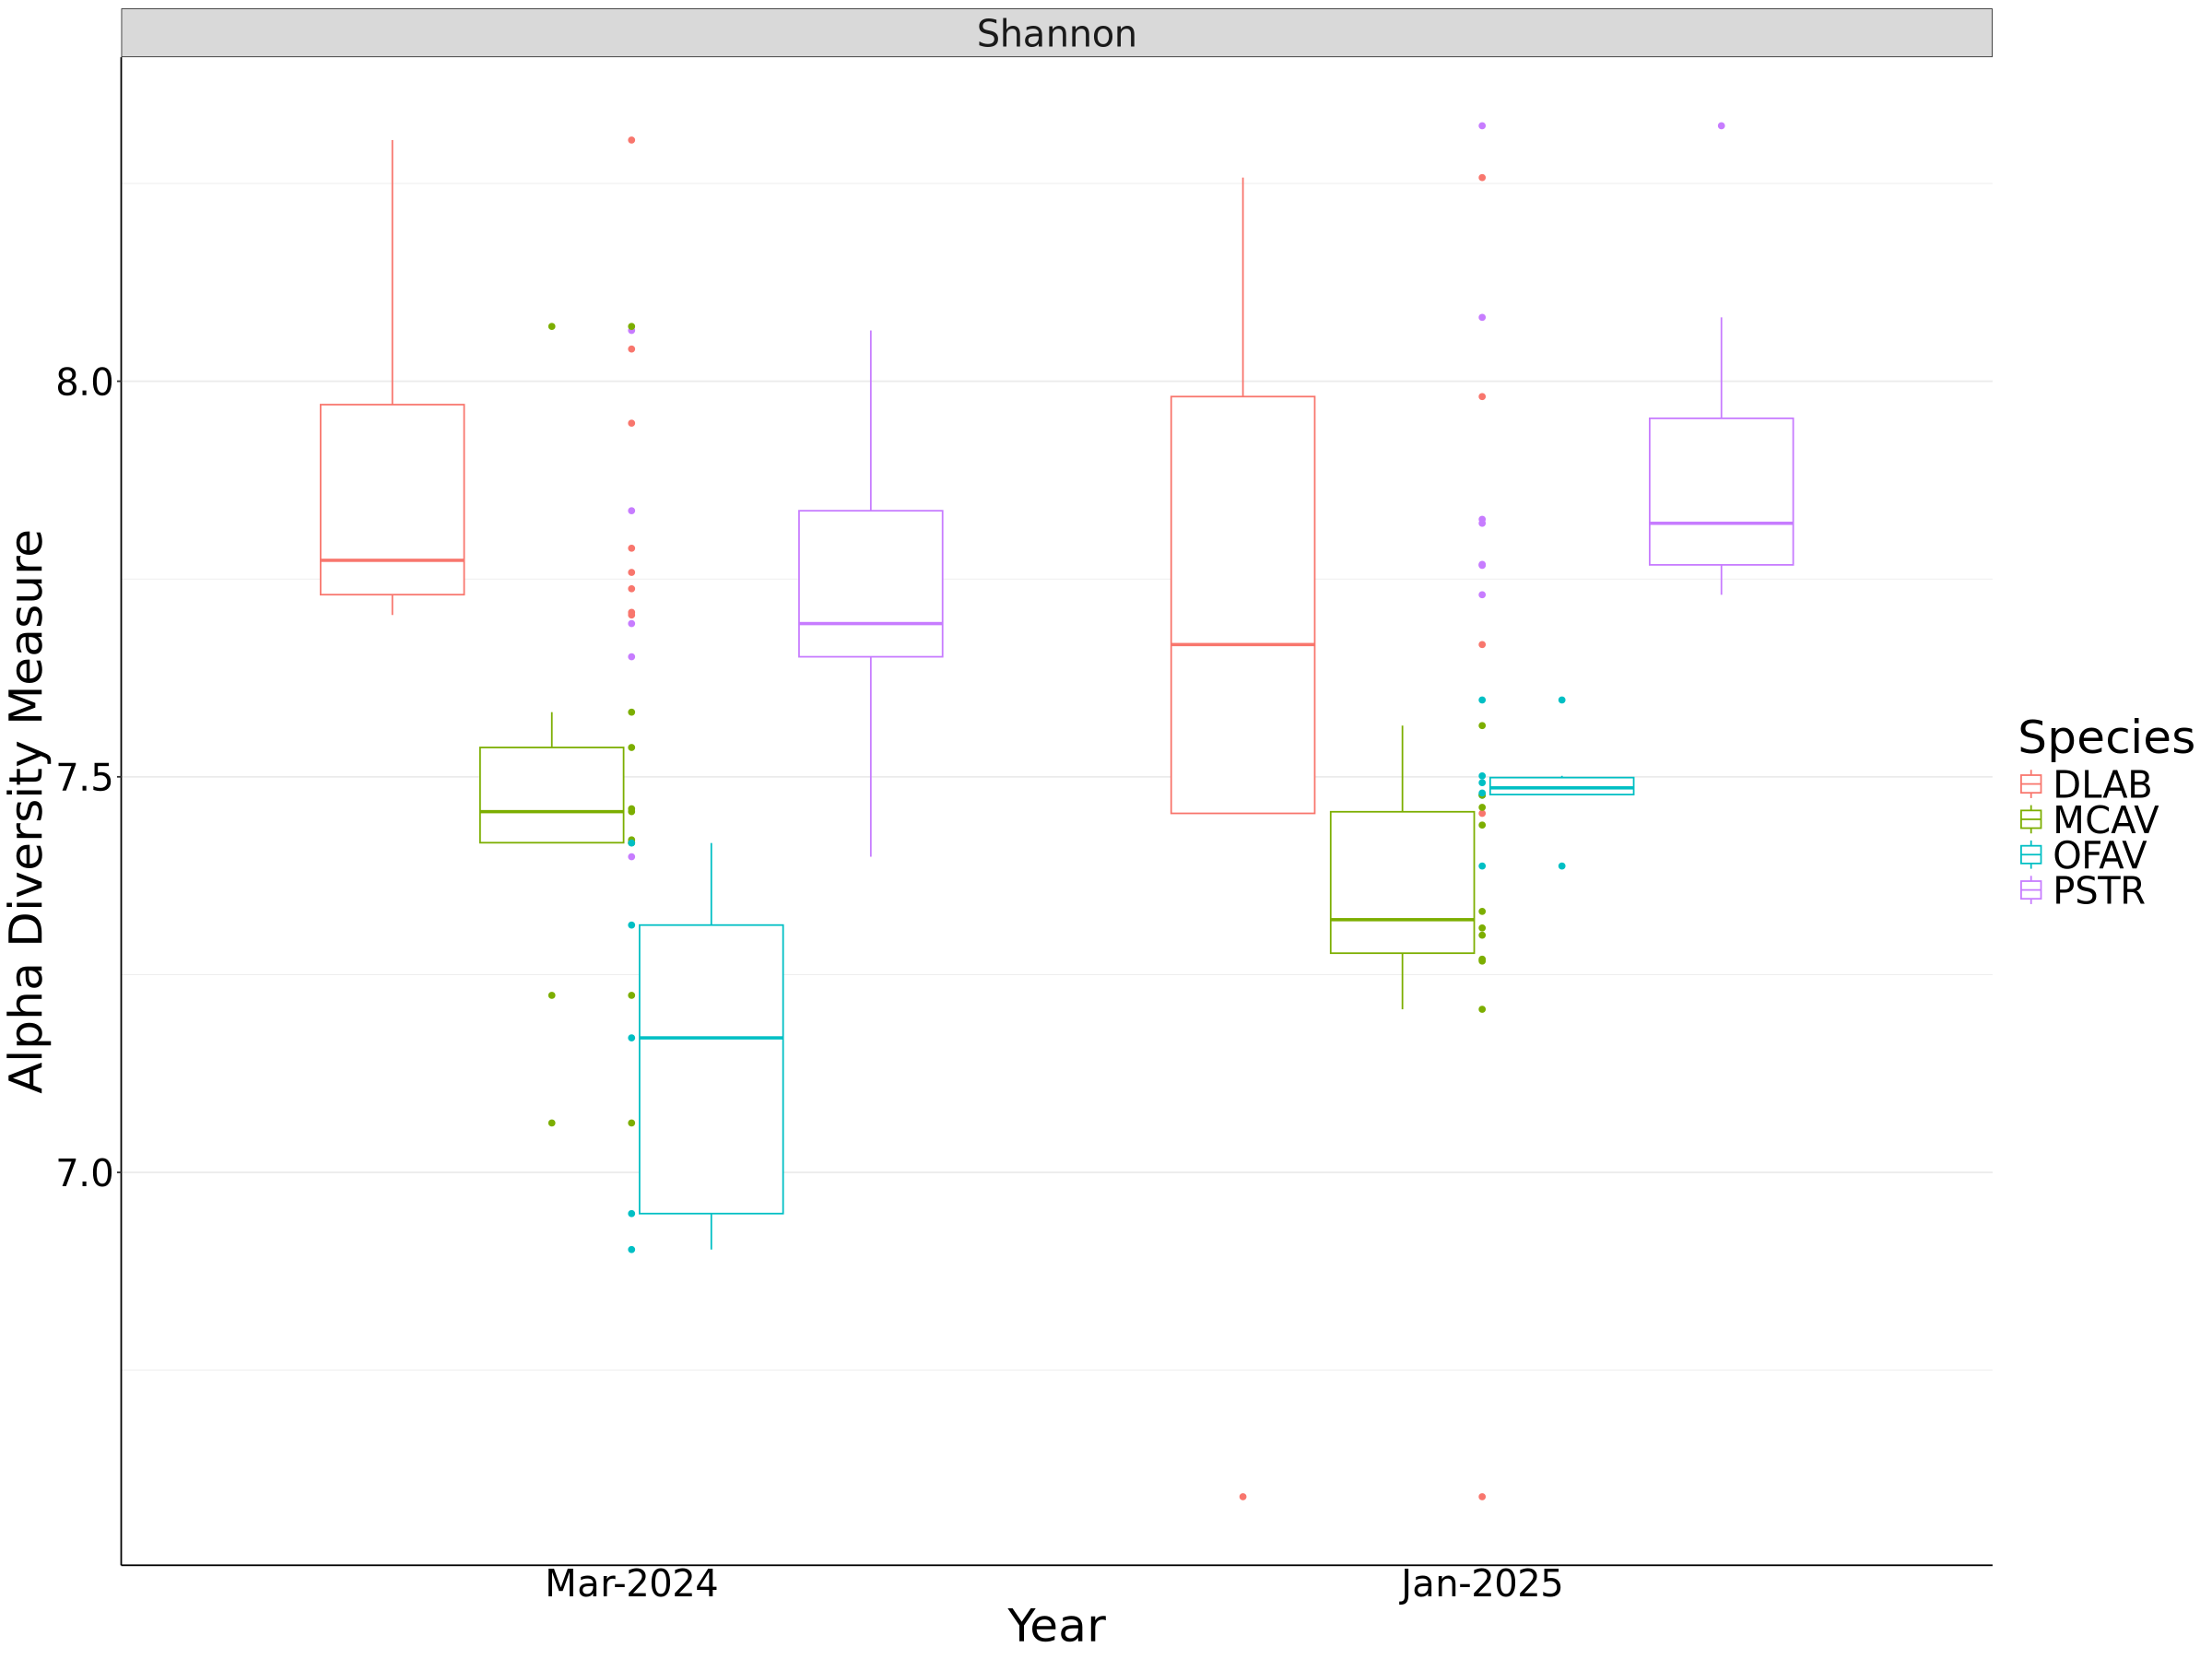

In [63]:
plot_richness(COL_all, x="Year", color="Species", measures=c("Shannon")) + geom_boxplot() + 
scale_x_discrete(limits = c("Mar-2024", "Jan-2025")) +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 30))

#### OFAV 

looking for most abundant taxa across both time points

In [65]:
#taxonomy file should be ready to go (same from above)
#read in normalized otu table
otu_ofav = read.csv('ofav_otu_normtable_species.csv',header=TRUE)
head(otu_ofav)

,X,X012025_COL_SAN_T5_568_OFAV_S1,X012025_COL_SAN_T5_572_OFAV_S5,X012025_COL_SAN_T5_580_OFAV_S13,X012025_COL_SAN_T5_584_OFAV_S17,X012025_COL_SAN_T5_585_OFAV_S18,X012025_COL_SAN_T5_596_OFAV_S29,X032024_COL_SAN_T5_139_OFAV_S17,X032024_COL_SAN_T5_140_OFAV_S18c,X032024_COL_SAN_T5_141_OFAV_S19,X032024_COL_SAN_T5_166_OFAV_S20,X032024_COL_SAN_T5_167_OFAV_S21,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2066072,34004.255,33729.125,32482.464,36195.557,35369.786,29709.214,39771.637,35468.461,44764.567,31327.225,37307.529,2224938.12
2,562,16079.761,15530.492,19944.404,12683.858,13428.151,15008.185,16906.544,11828.427,23289.127,15042.343,14923.012,552305.15
3,28213,13945.658,11060.559,18536.564,20117.656,12410.704,19984.773,0.000,15905.803,0.000,0.000,0.000,289710.30
4,2562892,9953.668,11437.926,10487.030,10795.394,10936.663,11600.056,16820.188,10859.546,16242.318,14098.292,13199.204,218889.60
5,4779,9562.361,8432.281,6340.802,7803.704,5863.806,6195.410,12953.368,6862.910,8294.441,7045.675,9468.451,145593.62
6,2093777,9503.172,7409.140,8010.887,8692.774,6899.230,5800.028,2504.318,8285.955,11760.085,6469.527,10484.415,96283.33


In [66]:
# rename first col as otu
names(otu_ofav)[1] <- "otu"

#remove X's from headers
names(otu_ofav) <- sub("^X", "", names(otu_ofav))
otu_table_ofav=as.data.frame(otu_ofav)

# make the index the otus
row.names(otu_table_ofav) <- otu_table_ofav$otu
otu_table_ofav$otu <- NULL
head(otu_table_ofav)

,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,012025_COL_SAN_T5_585_OFAV_S18,012025_COL_SAN_T5_596_OFAV_S29,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,Sum
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2066072,34004.255,33729.125,32482.464,36195.557,35369.786,29709.214,39771.637,35468.461,44764.567,31327.225,37307.529,2224938.12
562,16079.761,15530.492,19944.404,12683.858,13428.151,15008.185,16906.544,11828.427,23289.127,15042.343,14923.012,552305.15
28213,13945.658,11060.559,18536.564,20117.656,12410.704,19984.773,0.000,15905.803,0.000,0.000,0.000,289710.30
2562892,9953.668,11437.926,10487.030,10795.394,10936.663,11600.056,16820.188,10859.546,16242.318,14098.292,13199.204,218889.60
4779,9562.361,8432.281,6340.802,7803.704,5863.806,6195.410,12953.368,6862.910,8294.441,7045.675,9468.451,145593.62
2093777,9503.172,7409.140,8010.887,8692.774,6899.230,5800.028,2504.318,8285.955,11760.085,6469.527,10484.415,96283.33


In [67]:
# sort by most abundant OTUs
otus_sorted_ofav <- otu_table_ofav[order(rowSums(otu_table_ofav), decreasing = TRUE), ]
head(otus_sorted_ofav)

,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,012025_COL_SAN_T5_585_OFAV_S18,012025_COL_SAN_T5_596_OFAV_S29,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,Sum
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Total_reads,304109.000,376292.000,362257.000,308187.000,278147.000,306033.000,104220.000,297250.000,86564.000,144060.000,120083.000,20812867.0
2066072,34004.255,33729.125,32482.464,36195.557,35369.786,29709.214,39771.637,35468.461,44764.567,31327.225,37307.529,2224938.1
562,16079.761,15530.492,19944.404,12683.858,13428.151,15008.185,16906.544,11828.427,23289.127,15042.343,14923.012,552305.1
588596,9016.504,8461.514,8455.323,9241.143,8959.291,8165.786,9604.682,9204.373,10142.785,8586.700,9618.347,596684.6
2057741,3235.682,2662.826,6147.569,8082.755,2937.296,11126.251,4087.507,12174.937,6007.116,3526.308,4205.425,399117.5
28213,13945.658,11060.559,18536.564,20117.656,12410.704,19984.773,0.000,15905.803,0.000,0.000,0.000,289710.3


In [68]:
#remove total reads row
otus_sorted_ofav <- otus_sorted_ofav[-1, ]
head(otus_sorted_ofav)
dim (otus_sorted_ofav)

,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,012025_COL_SAN_T5_585_OFAV_S18,012025_COL_SAN_T5_596_OFAV_S29,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,Sum
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2066072,34004.255,33729.125,32482.464,36195.557,35369.786,29709.214,39771.637,35468.461,44764.567,31327.225,37307.529,2224938.1
562,16079.761,15530.492,19944.404,12683.858,13428.151,15008.185,16906.544,11828.427,23289.127,15042.343,14923.012,552305.1
588596,9016.504,8461.514,8455.323,9241.143,8959.291,8165.786,9604.682,9204.373,10142.785,8586.700,9618.347,596684.6
2057741,3235.682,2662.826,6147.569,8082.755,2937.296,11126.251,4087.507,12174.937,6007.116,3526.308,4205.425,399117.5
28213,13945.658,11060.559,18536.564,20117.656,12410.704,19984.773,0.000,15905.803,0.000,0.000,0.000,289710.3
2562892,9953.668,11437.926,10487.030,10795.394,10936.663,11600.056,16820.188,10859.546,16242.318,14098.292,13199.204,218889.6


[1] 13441    12

In [78]:
#remove Sum column
otus_sorted_ofav$Sum <- NULL
head(otus_sorted_ofav)

,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,012025_COL_SAN_T5_585_OFAV_S18,012025_COL_SAN_T5_596_OFAV_S29,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2066072,34004.255,33729.125,32482.464,36195.557,35369.786,29709.214,39771.637,35468.461,44764.567,31327.225,37307.529
562,16079.761,15530.492,19944.404,12683.858,13428.151,15008.185,16906.544,11828.427,23289.127,15042.343,14923.012
588596,9016.504,8461.514,8455.323,9241.143,8959.291,8165.786,9604.682,9204.373,10142.785,8586.700,9618.347
2057741,3235.682,2662.826,6147.569,8082.755,2937.296,11126.251,4087.507,12174.937,6007.116,3526.308,4205.425
28213,13945.658,11060.559,18536.564,20117.656,12410.704,19984.773,0.000,15905.803,0.000,0.000,0.000
2562892,9953.668,11437.926,10487.030,10795.394,10936.663,11600.056,16820.188,10859.546,16242.318,14098.292,13199.204


In [81]:
# Convert to matrix
otus_ofav=as.matrix(otus_sorted_ofav)
head(otus_ofav)

,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,012025_COL_SAN_T5_585_OFAV_S18,012025_COL_SAN_T5_596_OFAV_S29,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
2066072,34004.255,33729.125,32482.464,36195.557,35369.786,29709.214,39771.637,35468.461,44764.567,31327.225,37307.529
562,16079.761,15530.492,19944.404,12683.858,13428.151,15008.185,16906.544,11828.427,23289.127,15042.343,14923.012
588596,9016.504,8461.514,8455.323,9241.143,8959.291,8165.786,9604.682,9204.373,10142.785,8586.700,9618.347
2057741,3235.682,2662.826,6147.569,8082.755,2937.296,11126.251,4087.507,12174.937,6007.116,3526.308,4205.425
28213,13945.658,11060.559,18536.564,20117.656,12410.704,19984.773,0.000,15905.803,0.000,0.000,0.000
2562892,9953.668,11437.926,10487.030,10795.394,10936.663,11600.056,16820.188,10859.546,16242.318,14098.292,13199.204


In [72]:
#filter metadata for ofavs only
metadata_ofav <- metadata[metadata$Species=="OFAV",]
head(metadata_ofav)
dim(metadata_ofav)

,Transect,CollectionDate,Year,Tag,Species,Health_status_sampled,X032026_status,Antibiotic_Treatment,Probiotic_Experiment_Date,Probiotic_Treatment
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
012025_COL_SAN_T5_568_OFAV_S1,ELARBOL,1/17/25,Jan-2025,37,OFAV,Healthy,Healthy,Y-2025,,
012025_COL_SAN_T5_572_OFAV_S5,ELARBOL,1/17/25,Jan-2025,28,OFAV,Healthy,Healthy,Y-2025,Y-2026,Healthy_Treatment
012025_COL_SAN_T5_580_OFAV_S13,ELARBOL,1/17/25,Jan-2025,23,OFAV,Healthy,Healthy,,Y-2026,Healthy_Control
012025_COL_SAN_T5_584_OFAV_S17,ELARBOL,1/17/25,Jan-2025,22,OFAV,Healthy,Healthy,,Y-2026,Healthy_Control
012025_COL_SAN_T5_585_OFAV_S18,ELARBOL,1/17/25,Jan-2025,24,OFAV,Healthy,Diseased,,Y-2026,Disease_Treatment
012025_COL_SAN_T5_596_OFAV_S29,ELARBOL,1/17/25,Jan-2025,29,OFAV,Healthy,Healthy,,Y-2026,Healthy_Control


[1] 11 10

In [82]:
# classify phyloseq objects 
OTU_O=otu_table((otus_ofav), taxa_are_rows = TRUE)
TAX_O=tax_table(taxonomy)
SAMP_O=sample_data(metadata_ofav)

In [83]:
# Create phyloseq object
COL_ofav = phyloseq(OTU_O, SAMP_O, TAX_O)
COL_ofav

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 13441 taxa and 11 samples ]
sample_data() Sample Data:       [ 11 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 13441 taxa by 1 taxonomic ranks ]

In [85]:
COL_ofav_10 = prune_taxa(names(sort(taxa_sums(COL_ofav),TRUE)[1:10]), COL_ofav)
#if I want to make it normalized to 100, can do that but for right now just looking a absolute (following normalization)

In [96]:
#order of facets
sample_data(COL_ofav_10)$Year_o <- factor(sample_data(COL_ofav_10)$Year, 
                                      levels = c("Mar-2024", "Jan-2025"))

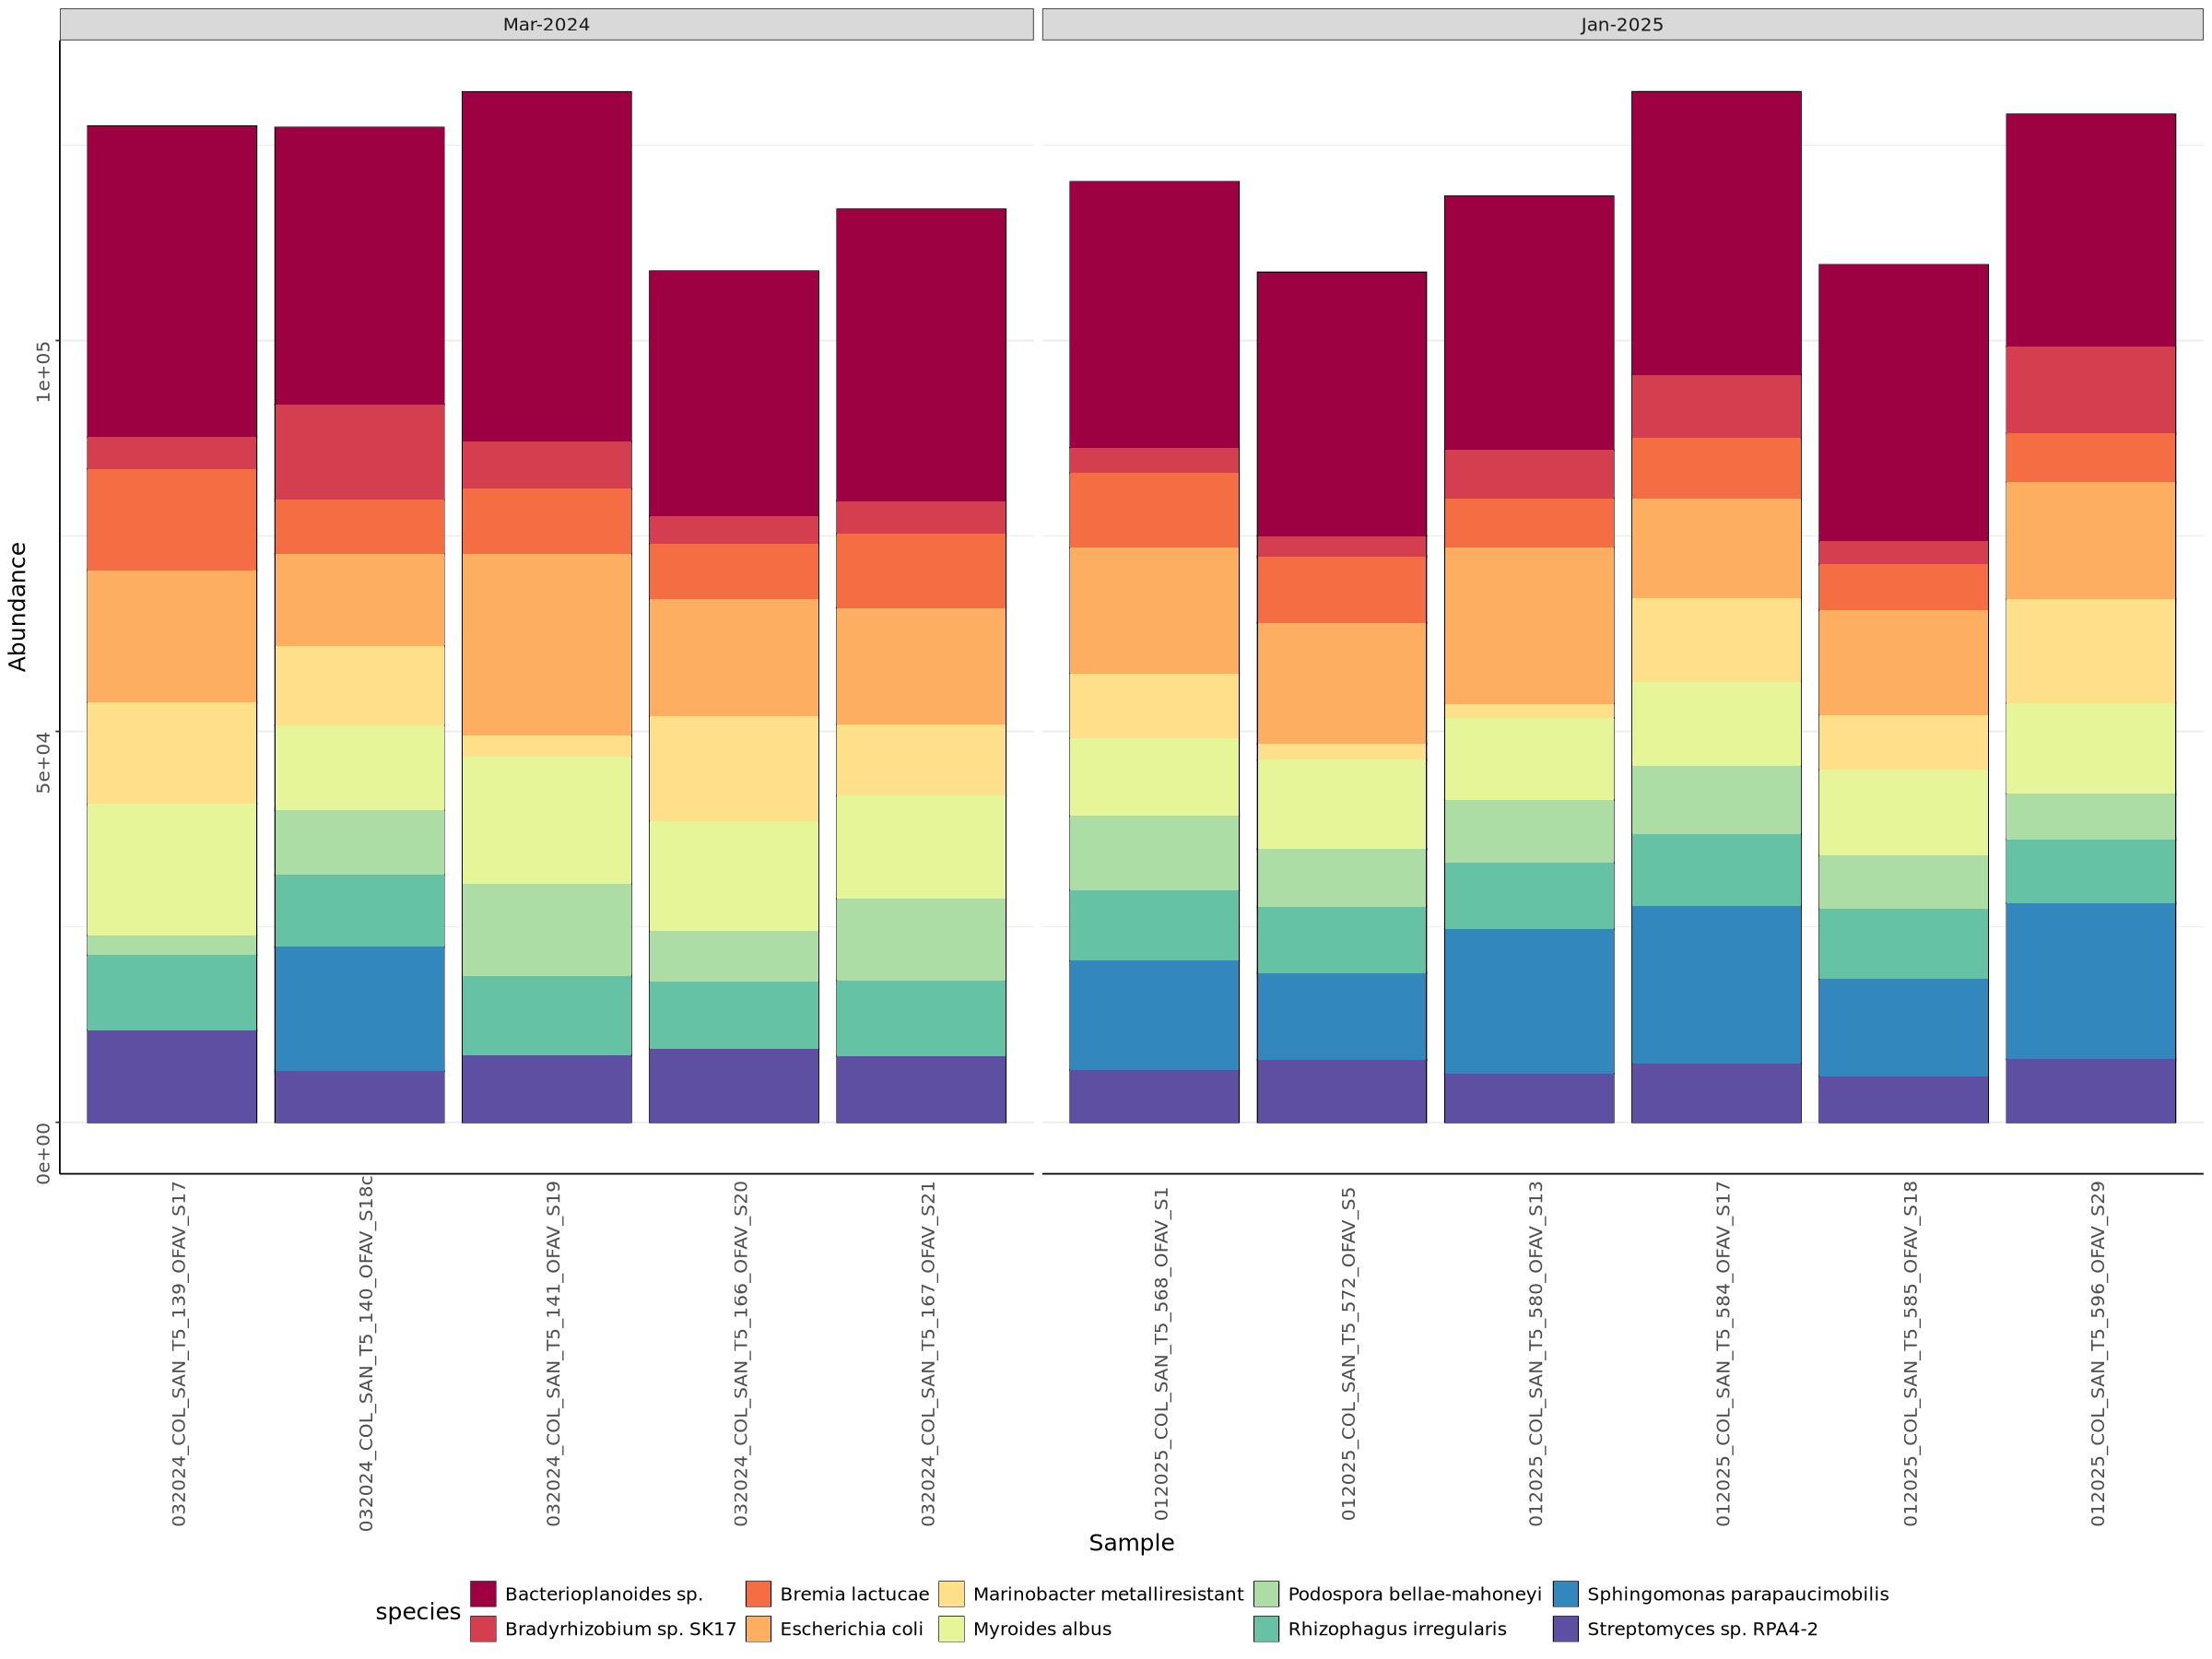

In [97]:
# bar plot of top 10 abundant taxa in OFAV samples
ofav_10_bar<-plot_bar(COL_ofav_10,fill='species')+
facet_grid(~Year_o, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_brewer(palette = "Spectral") +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
ofav_10_bar

Relative abundance plot

In [111]:
COL_ofav_10_rel <- transform_sample_counts(COL_ofav_10, function(x) x / sum(x))

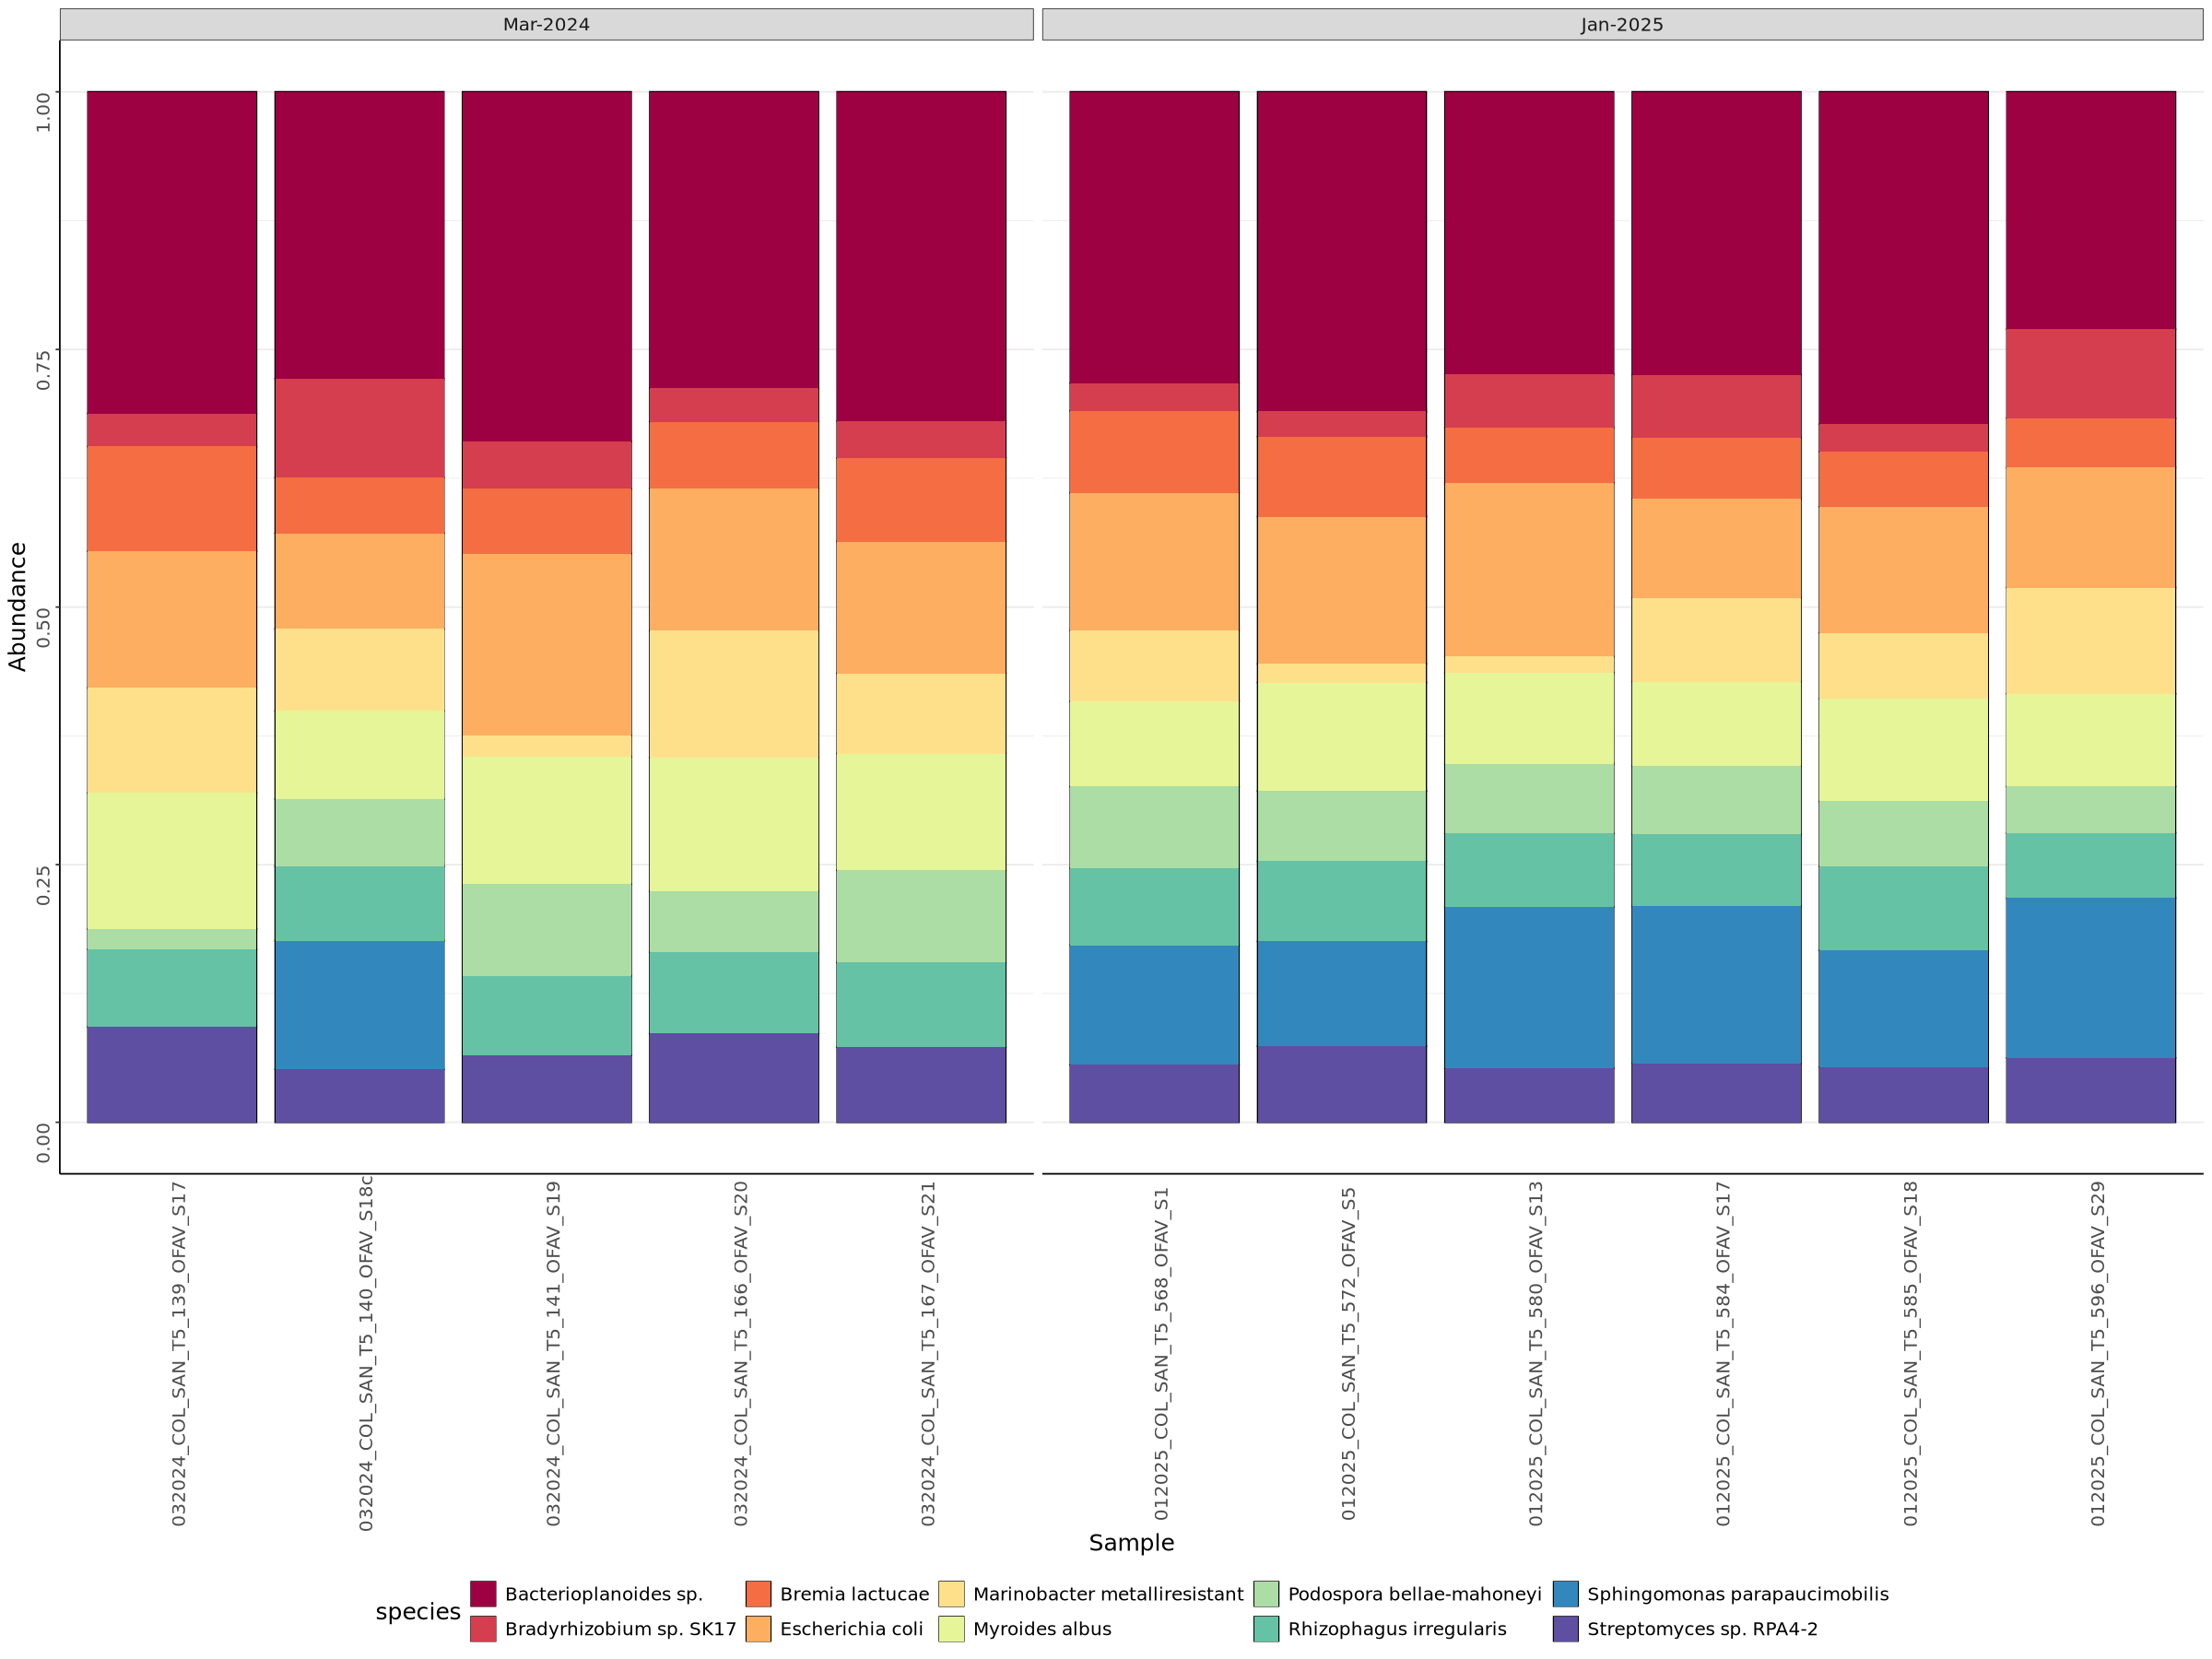

In [112]:
# bar plot of top 10 abundant taxa in OFAV samples
ofav_10_rel_bar<-plot_bar(COL_ofav_10_rel,fill='species')+
facet_grid(~Year_o, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_brewer(palette = "Spectral") +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
ofav_10_rel_bar

Top 50 taxa

In [115]:
#now do top 50
COL_ofav_50 = prune_taxa(names(sort(taxa_sums(COL_ofav),TRUE)[1:50]), COL_ofav)

In [116]:
sample_data(COL_ofav_50)$Year_o <- factor(sample_data(COL_ofav_50)$Year, 
                                      levels = c("Mar-2024", "Jan-2025"))

In [117]:
#from rampgenerator.com 
colors_50 <- c("#A6CEE3",
  "#88BBD8",
  "#69A7CE",
  "#4B94C3",
  "#2D81B9",
  "#3185AF",
  "#529CA5",
  "#73B39C",
  "#94CA93",
  "#AFDE88",
  "#93D073",
  "#76C15E",
  "#5AB349",
  "#3DA534",
  "#509F3C",
  "#7C9E54",
  "#A99C6D",
  "#D69B85",
  "#FA9594",
  "#F57878",
  "#EF5B5C",
  "#EA3F40",
  "#E42224",
  "#E7352A",
  "#ED5A3C",
  "#F37F4F",
  "#F9A461",
  "#FDBB68",
  "#FEAD4F",
  "#FE9E36",
  "#FE901D",
  "#FF8205",
  "#F58827",
  "#E99457",
  "#DD9F87",
  "#D2ABB7",
  "#C2A8D1",
  "#AD8EC4",
  "#9774B6",
  "#825AA9",
  "#6C3F9B",
  "#88659A",
  "#AA909A",
  "#CBBC99",
  "#EDE799",
  "#F7EE8D",
  "#E6C974",
  "#D4A45B",
  "#C37E41",
  "#B15928")

In [119]:
options(repr.plot.width=20, repr.plot.height=15)

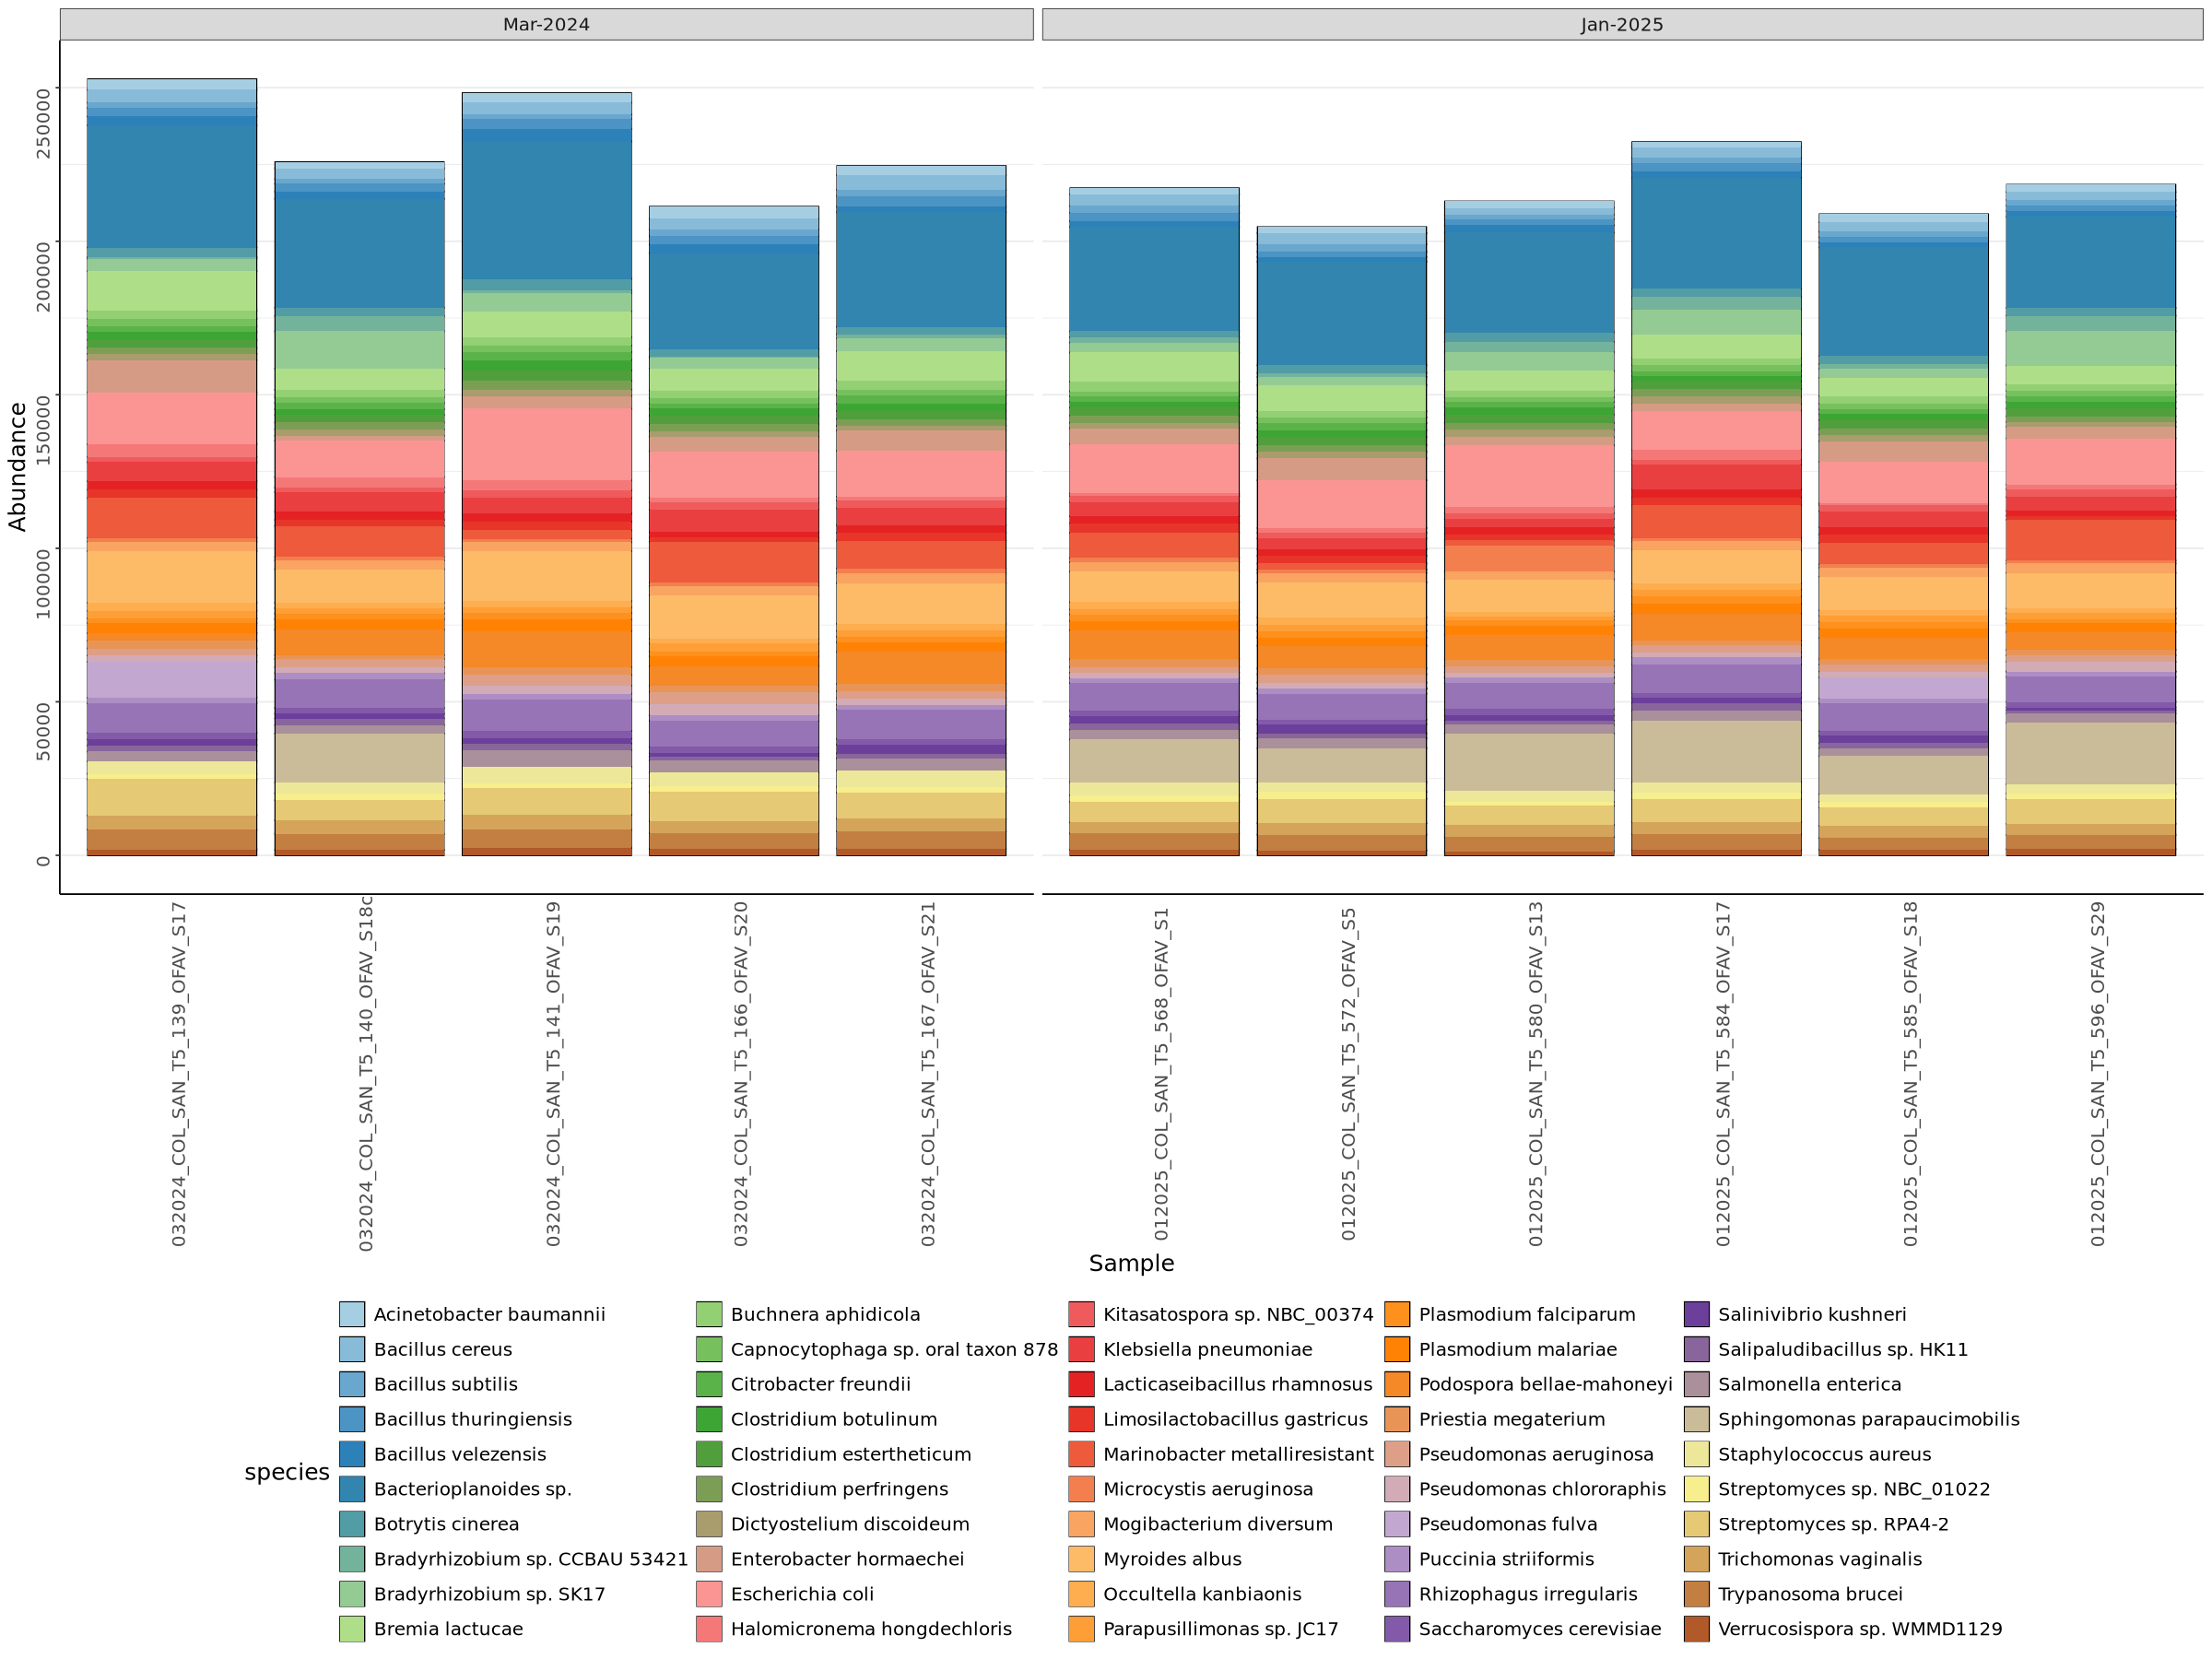

In [120]:
# bar plot of top 50 abundant taxa in OFAV samples
ofav_50_bar<-plot_bar(COL_ofav_50,fill='species')+
facet_grid(~Year_o, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_manual(values = colors_50) +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
ofav_50_bar

In [122]:
COL_ofav_50_rel <- transform_sample_counts(COL_ofav_50, function(x) x / sum(x))

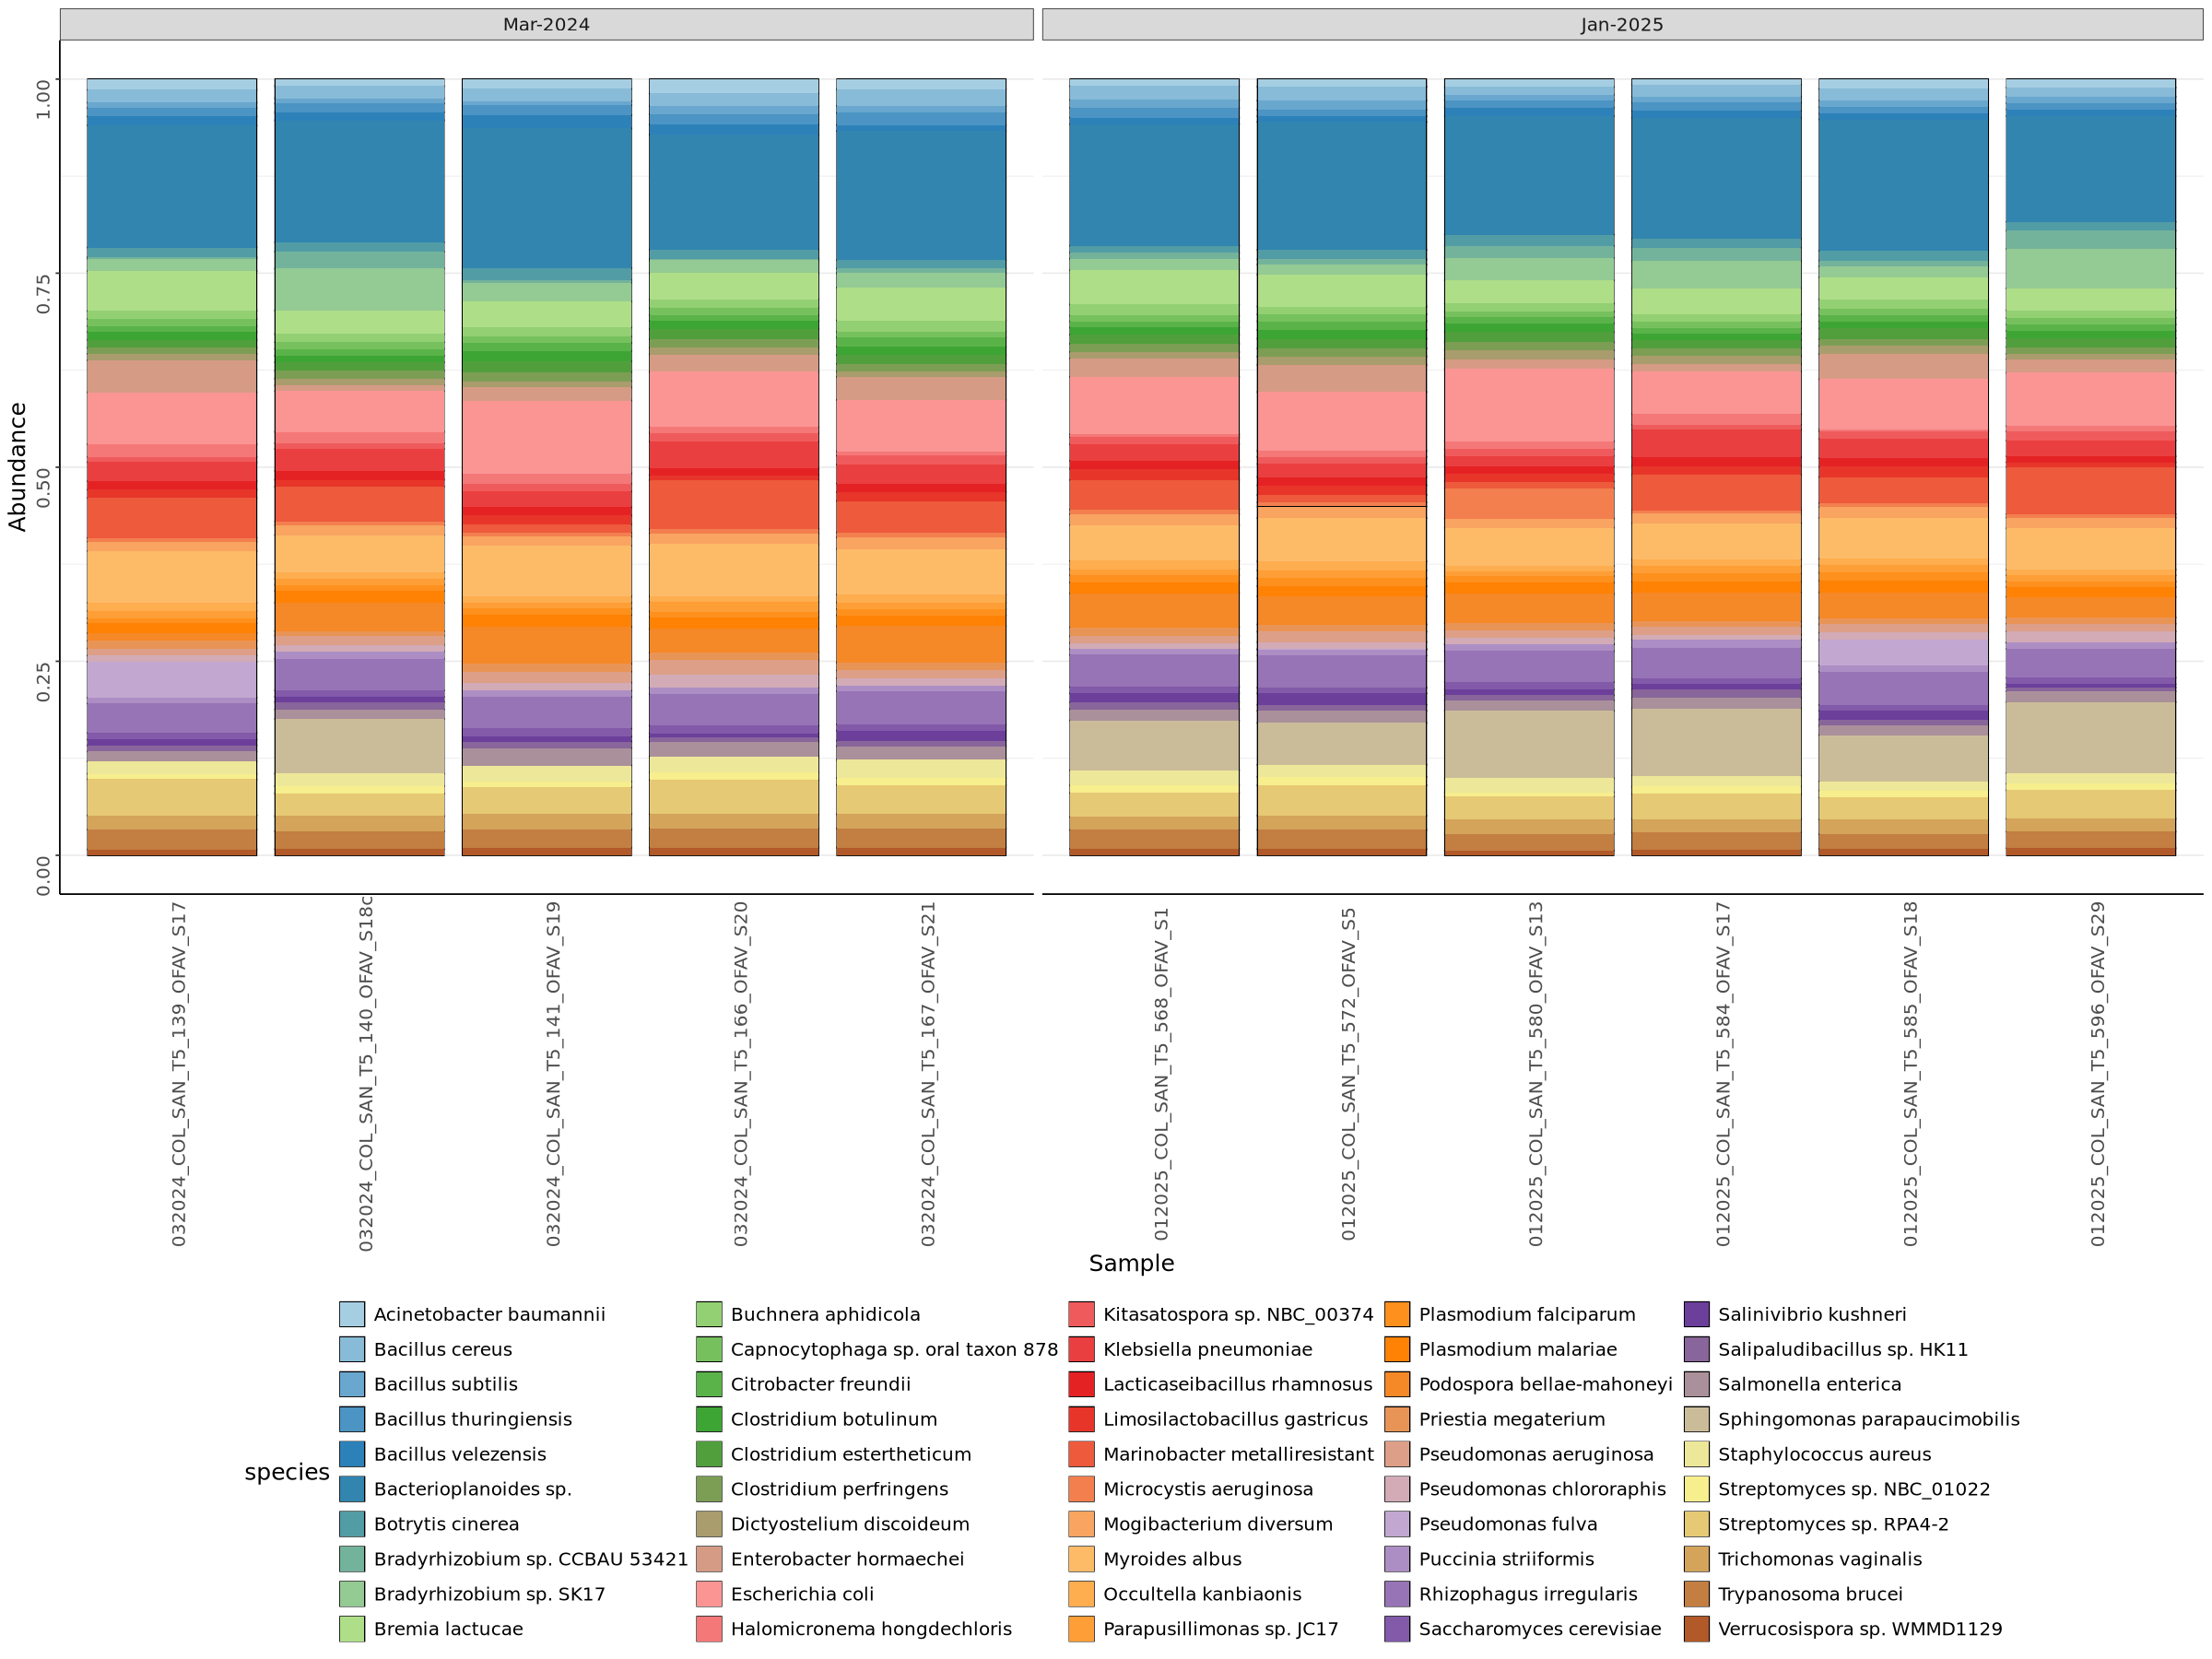

In [123]:
# bar plot of top 50 abundant taxa in OFAV samples
ofav_50_rel_bar<-plot_bar(COL_ofav_50_rel,fill='species')+
facet_grid(~Year_o, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_manual(values = colors_50) +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
ofav_50_rel_bar

not a whole lot of variability between OFAV samples, is this weird? Going to look at MCAV samples

### MCAV

In [128]:
getwd()

[1] "/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/kraken_bracken"

In [129]:
#taxonomy file should be ready to go (same from above)
#read in normalized otu table
otu_mcav = read.csv('mcav_otu_normtable_species.csv',header=TRUE)
head(otu_mcav)

,X,X012025_COL_SAN_T5_574_MCAV_S7,X012025_COL_SAN_T5_578_MCAV_S11,X012025_COL_SAN_T5_581_MCAV_S14,X012025_COL_SAN_T5_583_MCAV_S16,X012025_COL_SAN_T5_588_MCAV_S21,X012025_COL_SAN_T5_589_MCAV_S22,X012025_COL_SAN_T5_591_MCAV_S24,X012025_COL_SAN_T5_593_MCAV_S26,X012025_COL_SAN_T5_594_MCAV_S27,X012025_COL_SAN_T5_595_MCAV_S28,X032024_COL_SAN_T5_128_MCAV_S1,X032024_COL_SAN_T5_129_MCAV_S2,X032024_COL_SAN_T5_130_MCAV_S37,X032024_COL_SAN_T5_131_MCAV_S3,X032024_COL_SAN_T5_132_MCAV_S4,X032024_COL_SAN_T5_133_MCAV_S5,X032024_COL_SAN_T5_134_MCAV_S6,X032024_COL_SAN_T5_136_MCAV_S7,X032024_COL_SAN_T5_150_MCAV_S8
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2066072,56344.5236,45617.3886,65045.143,49956.274,42008.9662,49445.2691,55802.873,36505.8152,48917.7730,48124.6487,12855.71828,27768.8297,14490.1214,41763.194,30920.9119,15533.3328,37938.1314,34517.77311,16563.47603
2,562,7127.8399,4886.9333,6346.260,7207.262,7646.2690,3713.3010,11873.359,4542.3448,9979.8182,6430.5925,4714.38352,6764.7375,6518.5805,7582.950,6153.3411,4572.9351,8537.6447,9561.87228,5276.83092
3,28213,18874.1946,19042.8103,26050.244,24975.121,0.0000,26098.7698,0.000,17131.2427,19459.7197,0.0000,0.00000,0.0000,0.0000,0.000,0.0000,0.0000,0.0000,0.00000,77.83893
4,2562892,1322.4822,1725.1536,1705.926,2279.786,1775.0267,1182.4197,1801.123,791.5294,800.7925,1143.2164,2132.07716,1604.6864,4773.4487,2709.101,1367.9618,1598.8999,2535.4692,1659.82126,1200.01687
5,4779,1207.1889,1130.0658,1614.729,1206.236,1166.2836,1549.7245,1545.644,1054.0467,1462.7192,1300.4087,826.04036,1205.0061,1050.2377,1620.397,1188.8832,866.5793,1995.5082,1497.09369,515.68292
6,2093777,149.2031,108.1978,225.311,0.000,142.2297,231.4524,0.000,226.7195,245.3295,304.8577,74.41805,113.3422,102.6548,0.000,149.2322,126.1219,226.9401,97.63654,61.62249


In [130]:
# rename first col as otu
names(otu_mcav)[1] <- "otu"

#remove X's from headers
names(otu_mcav) <- sub("^X", "", names(otu_mcav))
otu_table_mcav=as.data.frame(otu_mcav)

# make the index the otus
row.names(otu_table_mcav) <- otu_table_mcav$otu
otu_table_mcav$otu <- NULL
head(otu_table_mcav)

,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_578_MCAV_S11,012025_COL_SAN_T5_581_MCAV_S14,012025_COL_SAN_T5_583_MCAV_S16,012025_COL_SAN_T5_588_MCAV_S21,012025_COL_SAN_T5_589_MCAV_S22,012025_COL_SAN_T5_591_MCAV_S24,012025_COL_SAN_T5_593_MCAV_S26,012025_COL_SAN_T5_594_MCAV_S27,012025_COL_SAN_T5_595_MCAV_S28,032024_COL_SAN_T5_128_MCAV_S1,032024_COL_SAN_T5_129_MCAV_S2,032024_COL_SAN_T5_130_MCAV_S37,032024_COL_SAN_T5_131_MCAV_S3,032024_COL_SAN_T5_132_MCAV_S4,032024_COL_SAN_T5_133_MCAV_S5,032024_COL_SAN_T5_134_MCAV_S6,032024_COL_SAN_T5_136_MCAV_S7,032024_COL_SAN_T5_150_MCAV_S8
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2066072,56344.5236,45617.3886,65045.143,49956.274,42008.9662,49445.2691,55802.873,36505.8152,48917.7730,48124.6487,12855.71828,27768.8297,14490.1214,41763.194,30920.9119,15533.3328,37938.1314,34517.77311,16563.47603
562,7127.8399,4886.9333,6346.260,7207.262,7646.2690,3713.3010,11873.359,4542.3448,9979.8182,6430.5925,4714.38352,6764.7375,6518.5805,7582.950,6153.3411,4572.9351,8537.6447,9561.87228,5276.83092
28213,18874.1946,19042.8103,26050.244,24975.121,0.0000,26098.7698,0.000,17131.2427,19459.7197,0.0000,0.00000,0.0000,0.0000,0.000,0.0000,0.0000,0.0000,0.00000,77.83893
2562892,1322.4822,1725.1536,1705.926,2279.786,1775.0267,1182.4197,1801.123,791.5294,800.7925,1143.2164,2132.07716,1604.6864,4773.4487,2709.101,1367.9618,1598.8999,2535.4692,1659.82126,1200.01687
4779,1207.1889,1130.0658,1614.729,1206.236,1166.2836,1549.7245,1545.644,1054.0467,1462.7192,1300.4087,826.04036,1205.0061,1050.2377,1620.397,1188.8832,866.5793,1995.5082,1497.09369,515.68292
2093777,149.2031,108.1978,225.311,0.000,142.2297,231.4524,0.000,226.7195,245.3295,304.8577,74.41805,113.3422,102.6548,0.000,149.2322,126.1219,226.9401,97.63654,61.62249


In [131]:
# sort by most abundant OTUs
otus_sorted_mcav <- otu_table_mcav[order(rowSums(otu_table_mcav), decreasing = TRUE), ]
head(otus_sorted_mcav)

,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_578_MCAV_S11,012025_COL_SAN_T5_581_MCAV_S14,012025_COL_SAN_T5_583_MCAV_S16,012025_COL_SAN_T5_588_MCAV_S21,012025_COL_SAN_T5_589_MCAV_S22,012025_COL_SAN_T5_591_MCAV_S24,012025_COL_SAN_T5_593_MCAV_S26,012025_COL_SAN_T5_594_MCAV_S27,012025_COL_SAN_T5_595_MCAV_S28,032024_COL_SAN_T5_128_MCAV_S1,032024_COL_SAN_T5_129_MCAV_S2,032024_COL_SAN_T5_130_MCAV_S37,032024_COL_SAN_T5_131_MCAV_S3,032024_COL_SAN_T5_132_MCAV_S4,032024_COL_SAN_T5_133_MCAV_S5,032024_COL_SAN_T5_134_MCAV_S6,032024_COL_SAN_T5_136_MCAV_S7,032024_COL_SAN_T5_150_MCAV_S8
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Total_reads,147450.000,166362.000,186409.000,165805.000,175772.000,198745.000,156569.00,251412.000,216036.000,209934.000,268752.000,167634.000,253276.000,78993.000,201029.000,245794.000,127787.000,153631.000,308329.00000
2066072,56344.524,45617.389,65045.143,49956.274,42008.966,49445.269,55802.87,36505.815,48917.773,48124.649,12855.718,27768.830,14490.121,41763.194,30920.912,15533.333,37938.131,34517.773,16563.47603
588596,17300.780,15682.668,16431.610,19565.152,11901.782,18174.042,18062.32,15329.419,23070.229,17719.855,13603.620,14782.204,21569.355,23710.962,16306.105,13275.344,20988.050,23693.135,8374.17175
28213,18874.195,19042.810,26050.244,24975.121,0.000,26098.770,0.00,17131.243,19459.720,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,77.83893
573,4971.177,5962.900,4817.364,8353.186,6519.810,8156.180,11790.33,9009.117,10377.900,4839.616,4390.665,7188.279,6455.408,8912.182,5058.972,5854.496,9054.129,10225.801,12678.01602
562,7127.840,4886.933,6346.260,7207.262,7646.269,3713.301,11873.36,4542.345,9979.818,6430.592,4714.384,6764.737,6518.581,7582.950,6153.341,4572.935,8537.645,9561.872,5276.83092


In [132]:
#remove total reads row
otus_sorted_mcav <- otus_sorted_mcav[-1, ]
head(otus_sorted_mcav)
dim (otus_sorted_mcav)

,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_578_MCAV_S11,012025_COL_SAN_T5_581_MCAV_S14,012025_COL_SAN_T5_583_MCAV_S16,012025_COL_SAN_T5_588_MCAV_S21,012025_COL_SAN_T5_589_MCAV_S22,012025_COL_SAN_T5_591_MCAV_S24,012025_COL_SAN_T5_593_MCAV_S26,012025_COL_SAN_T5_594_MCAV_S27,012025_COL_SAN_T5_595_MCAV_S28,032024_COL_SAN_T5_128_MCAV_S1,032024_COL_SAN_T5_129_MCAV_S2,032024_COL_SAN_T5_130_MCAV_S37,032024_COL_SAN_T5_131_MCAV_S3,032024_COL_SAN_T5_132_MCAV_S4,032024_COL_SAN_T5_133_MCAV_S5,032024_COL_SAN_T5_134_MCAV_S6,032024_COL_SAN_T5_136_MCAV_S7,032024_COL_SAN_T5_150_MCAV_S8
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2066072,56344.524,45617.389,65045.143,49956.274,42008.9662,49445.269,55802.8729,36505.815,48917.773,48124.6487,12855.718,27768.830,14490.121,41763.194,30920.912,15533.333,37938.131,34517.773,16563.47603
588596,17300.780,15682.668,16431.610,19565.152,11901.7819,18174.042,18062.3240,15329.419,23070.229,17719.8548,13603.620,14782.204,21569.355,23710.962,16306.105,13275.344,20988.050,23693.135,8374.17175
28213,18874.195,19042.810,26050.244,24975.121,0.0000,26098.770,0.0000,17131.243,19459.720,0.0000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,77.83893
573,4971.177,5962.900,4817.364,8353.186,6519.8098,8156.180,11790.3289,9009.117,10377.900,4839.6163,4390.665,7188.279,6455.408,8912.182,5058.972,5854.496,9054.129,10225.801,12678.01602
562,7127.840,4886.933,6346.260,7207.262,7646.2690,3713.301,11873.3593,4542.345,9979.818,6430.5925,4714.384,6764.737,6518.581,7582.950,6153.341,4572.935,8537.645,9561.872,5276.83092
2057741,4367.582,6648.153,5858.086,6181.961,512.0269,7054.266,312.9611,7660.732,5207.465,185.7727,6321.813,12527.292,16760.372,5823.301,2089.251,2233.578,4609.233,1770.476,4219.51876


[1] 13441    19

In [133]:
# Convert to matrix
otus_mcav=as.matrix(otus_sorted_mcav)
head(otus_mcav)

,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_578_MCAV_S11,012025_COL_SAN_T5_581_MCAV_S14,012025_COL_SAN_T5_583_MCAV_S16,012025_COL_SAN_T5_588_MCAV_S21,012025_COL_SAN_T5_589_MCAV_S22,012025_COL_SAN_T5_591_MCAV_S24,012025_COL_SAN_T5_593_MCAV_S26,012025_COL_SAN_T5_594_MCAV_S27,012025_COL_SAN_T5_595_MCAV_S28,032024_COL_SAN_T5_128_MCAV_S1,032024_COL_SAN_T5_129_MCAV_S2,032024_COL_SAN_T5_130_MCAV_S37,032024_COL_SAN_T5_131_MCAV_S3,032024_COL_SAN_T5_132_MCAV_S4,032024_COL_SAN_T5_133_MCAV_S5,032024_COL_SAN_T5_134_MCAV_S6,032024_COL_SAN_T5_136_MCAV_S7,032024_COL_SAN_T5_150_MCAV_S8
2066072,56344.524,45617.389,65045.143,49956.274,42008.9662,49445.269,55802.8729,36505.815,48917.773,48124.6487,12855.718,27768.830,14490.121,41763.194,30920.912,15533.333,37938.131,34517.773,16563.47603
588596,17300.780,15682.668,16431.610,19565.152,11901.7819,18174.042,18062.3240,15329.419,23070.229,17719.8548,13603.620,14782.204,21569.355,23710.962,16306.105,13275.344,20988.050,23693.135,8374.17175
28213,18874.195,19042.810,26050.244,24975.121,0.0000,26098.770,0.0000,17131.243,19459.720,0.0000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,77.83893
573,4971.177,5962.900,4817.364,8353.186,6519.8098,8156.180,11790.3289,9009.117,10377.900,4839.6163,4390.665,7188.279,6455.408,8912.182,5058.972,5854.496,9054.129,10225.801,12678.01602
562,7127.840,4886.933,6346.260,7207.262,7646.2690,3713.301,11873.3593,4542.345,9979.818,6430.5925,4714.384,6764.737,6518.581,7582.950,6153.341,4572.935,8537.645,9561.872,5276.83092
2057741,4367.582,6648.153,5858.086,6181.961,512.0269,7054.266,312.9611,7660.732,5207.465,185.7727,6321.813,12527.292,16760.372,5823.301,2089.251,2233.578,4609.233,1770.476,4219.51876


In [134]:
#filter metadata for ofavs only
metadata_mcav <- metadata[metadata$Species=="MCAV",]
head(metadata_mcav)
dim(metadata_mcav)

,Transect,CollectionDate,Year,Tag,Species,Health_status_sampled,X032026_status,Antibiotic_Treatment,Probiotic_Experiment_Date,Probiotic_Treatment
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
012025_COL_SAN_T5_574_MCAV_S7,ELARBOL,1/17/25,Jan-2025,14,MCAV,Healthy,Diseased,,,
012025_COL_SAN_T5_578_MCAV_S11,ELARBOL,1/17/25,Jan-2025,10,MCAV,Healthy,Healthy,,,
012025_COL_SAN_T5_581_MCAV_S14,ELARBOL,1/17/25,Jan-2025,5,MCAV,Healthy,Healthy,,,
012025_COL_SAN_T5_583_MCAV_S16,ELARBOL,1/17/25,Jan-2025,7,MCAV,Healthy,Healthy,,,
012025_COL_SAN_T5_588_MCAV_S21,ELARBOL,1/17/25,Jan-2025,8,MCAV,Healthy,Healthy,,,
012025_COL_SAN_T5_589_MCAV_S22,ELARBOL,1/17/25,Jan-2025,6,MCAV,Healthy,Healthy,,,


[1] 19 10

In [135]:
# classify phyloseq objects 
OTU_M=otu_table((otus_mcav), taxa_are_rows = TRUE)
TAX_M=tax_table(taxonomy)
SAMP_M=sample_data(metadata_mcav)

In [136]:
# Create phyloseq object
COL_mcav = phyloseq(OTU_M, SAMP_M, TAX_M)
COL_mcav

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 13441 taxa and 19 samples ]
sample_data() Sample Data:       [ 19 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 13441 taxa by 1 taxonomic ranks ]

In [137]:
COL_mcav_10 = prune_taxa(names(sort(taxa_sums(COL_mcav),TRUE)[1:10]), COL_mcav)

In [138]:
#order of facets
sample_data(COL_mcav_10)$Year_m <- factor(sample_data(COL_mcav_10)$Year, 
                                      levels = c("Mar-2024", "Jan-2025"))

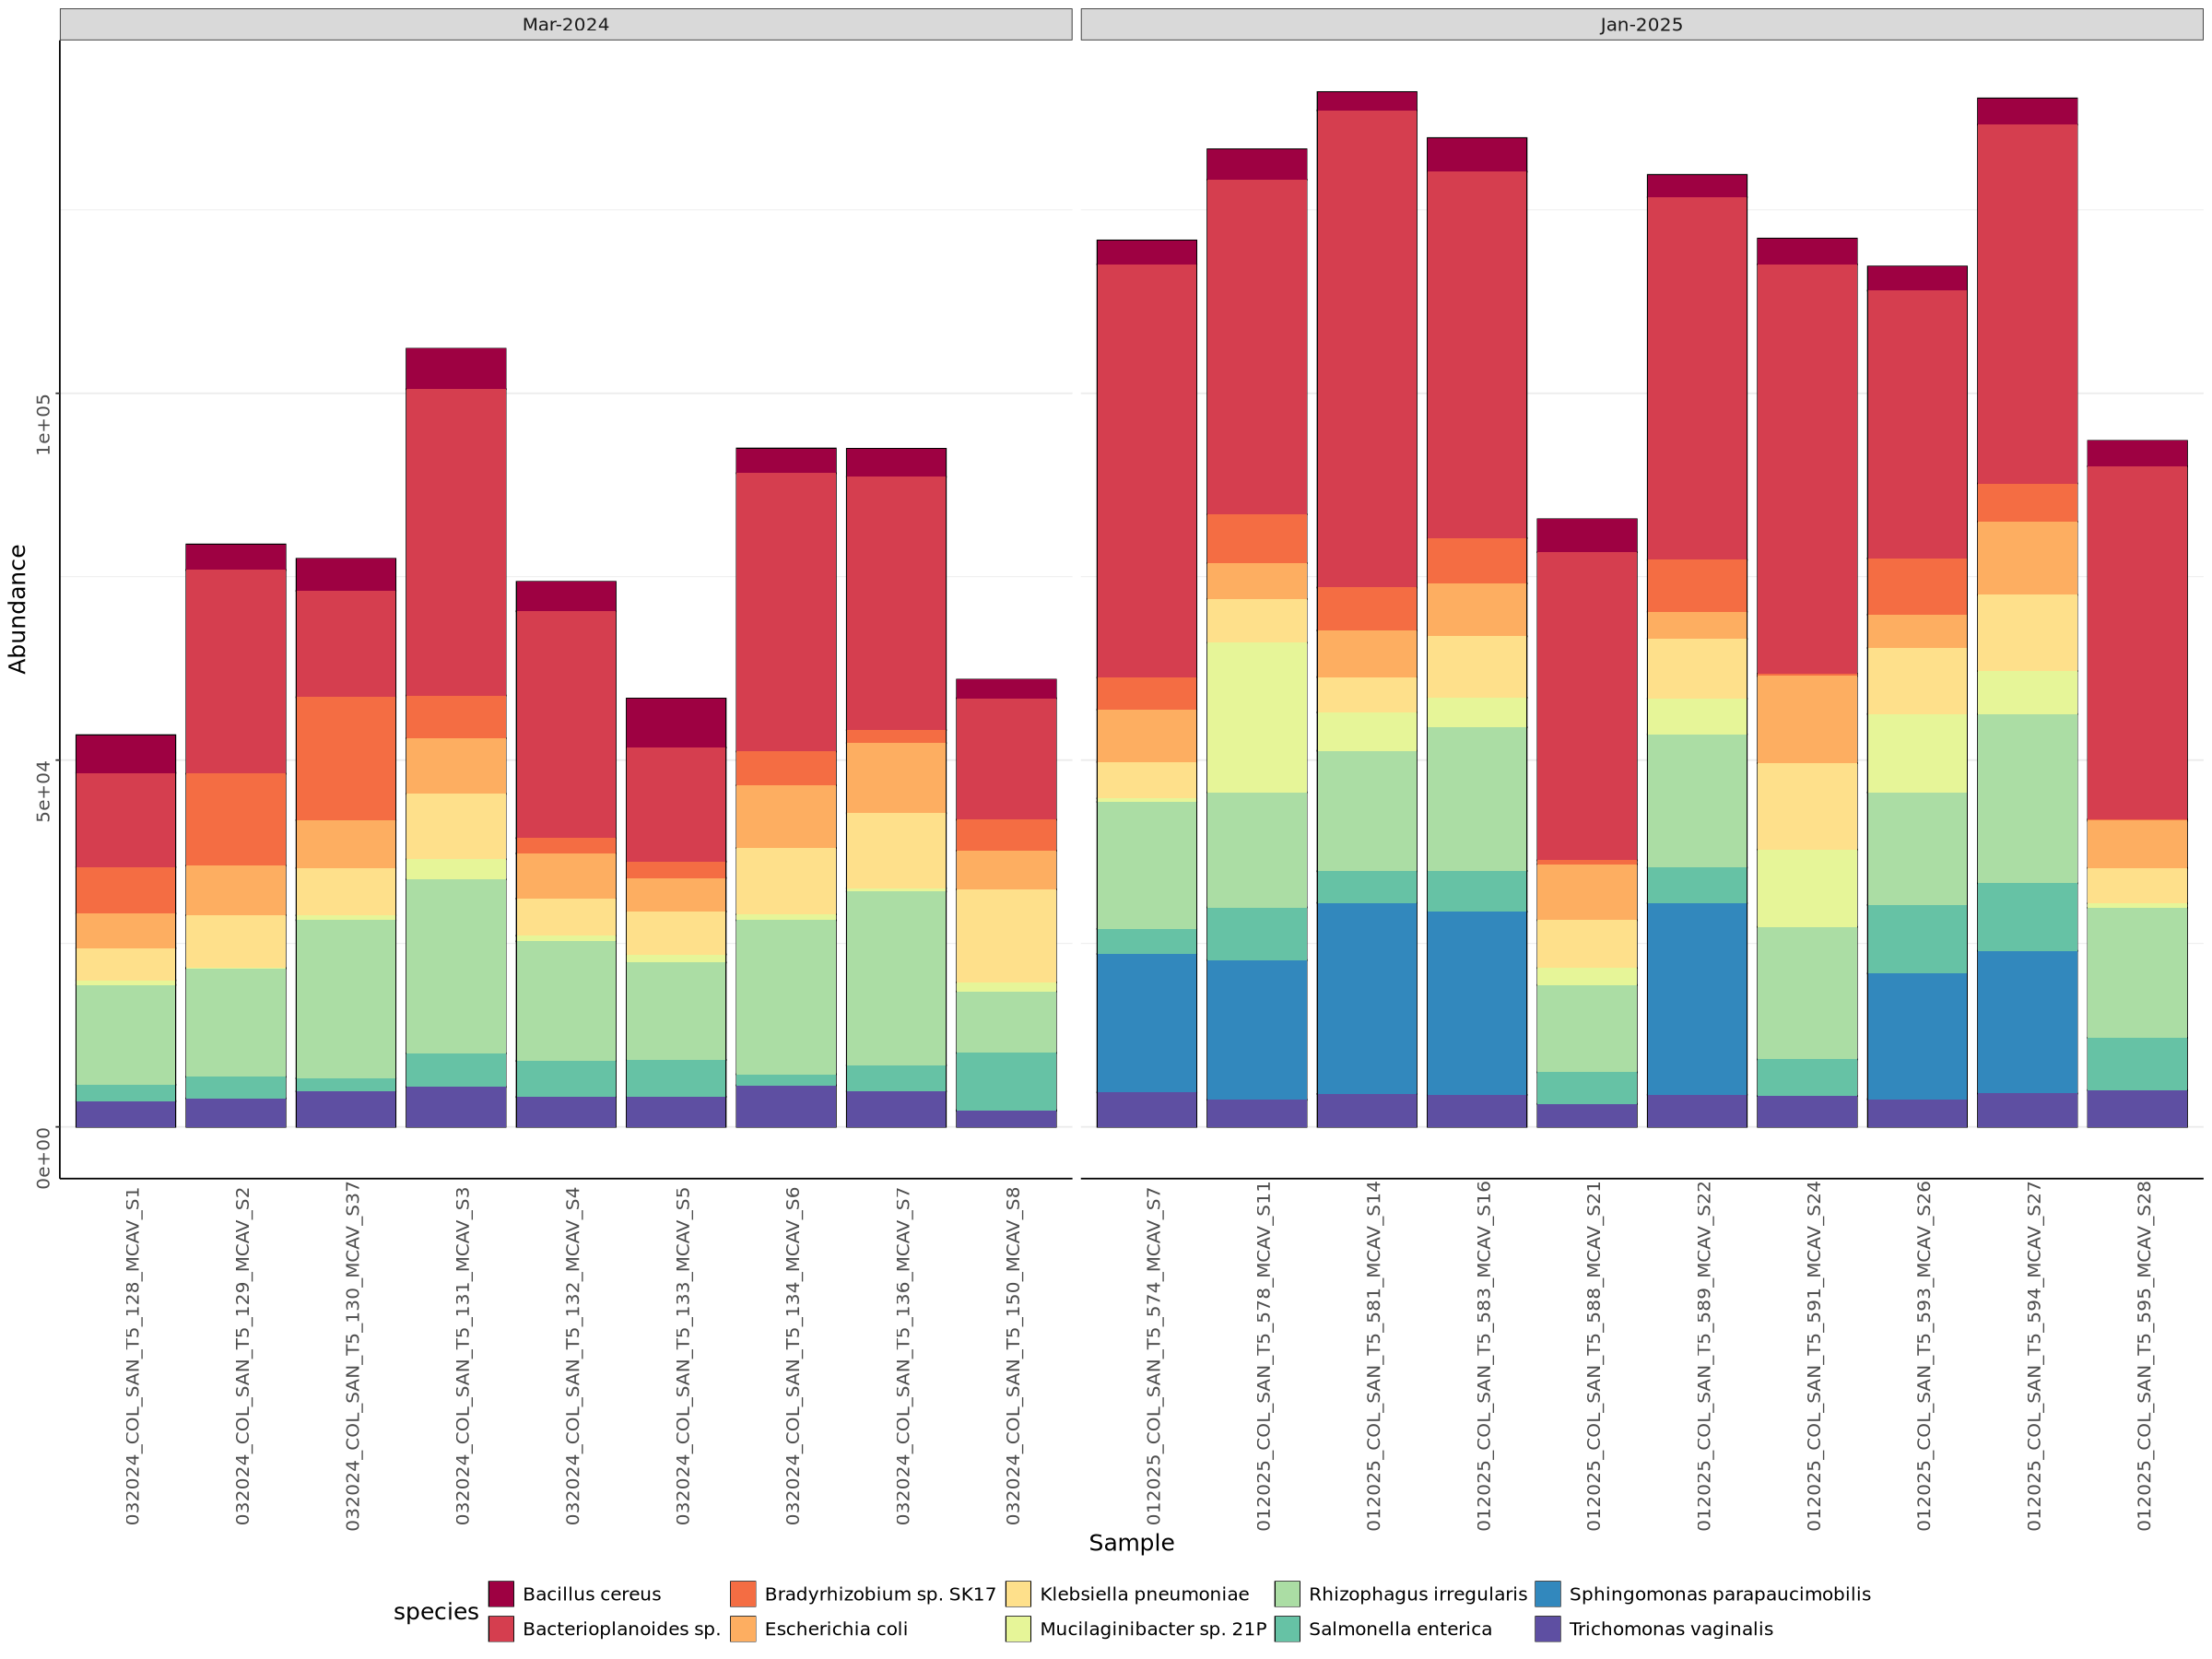

In [139]:
# bar plot of top 10 abundant taxa in MCAV samples
mcav_10_bar<-plot_bar(COL_mcav_10,fill='species')+
facet_grid(~Year_m, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_brewer(palette = "Spectral") +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
mcav_10_bar

In [140]:
COL_mcav_10_rel <- transform_sample_counts(COL_mcav_10, function(x) x / sum(x))

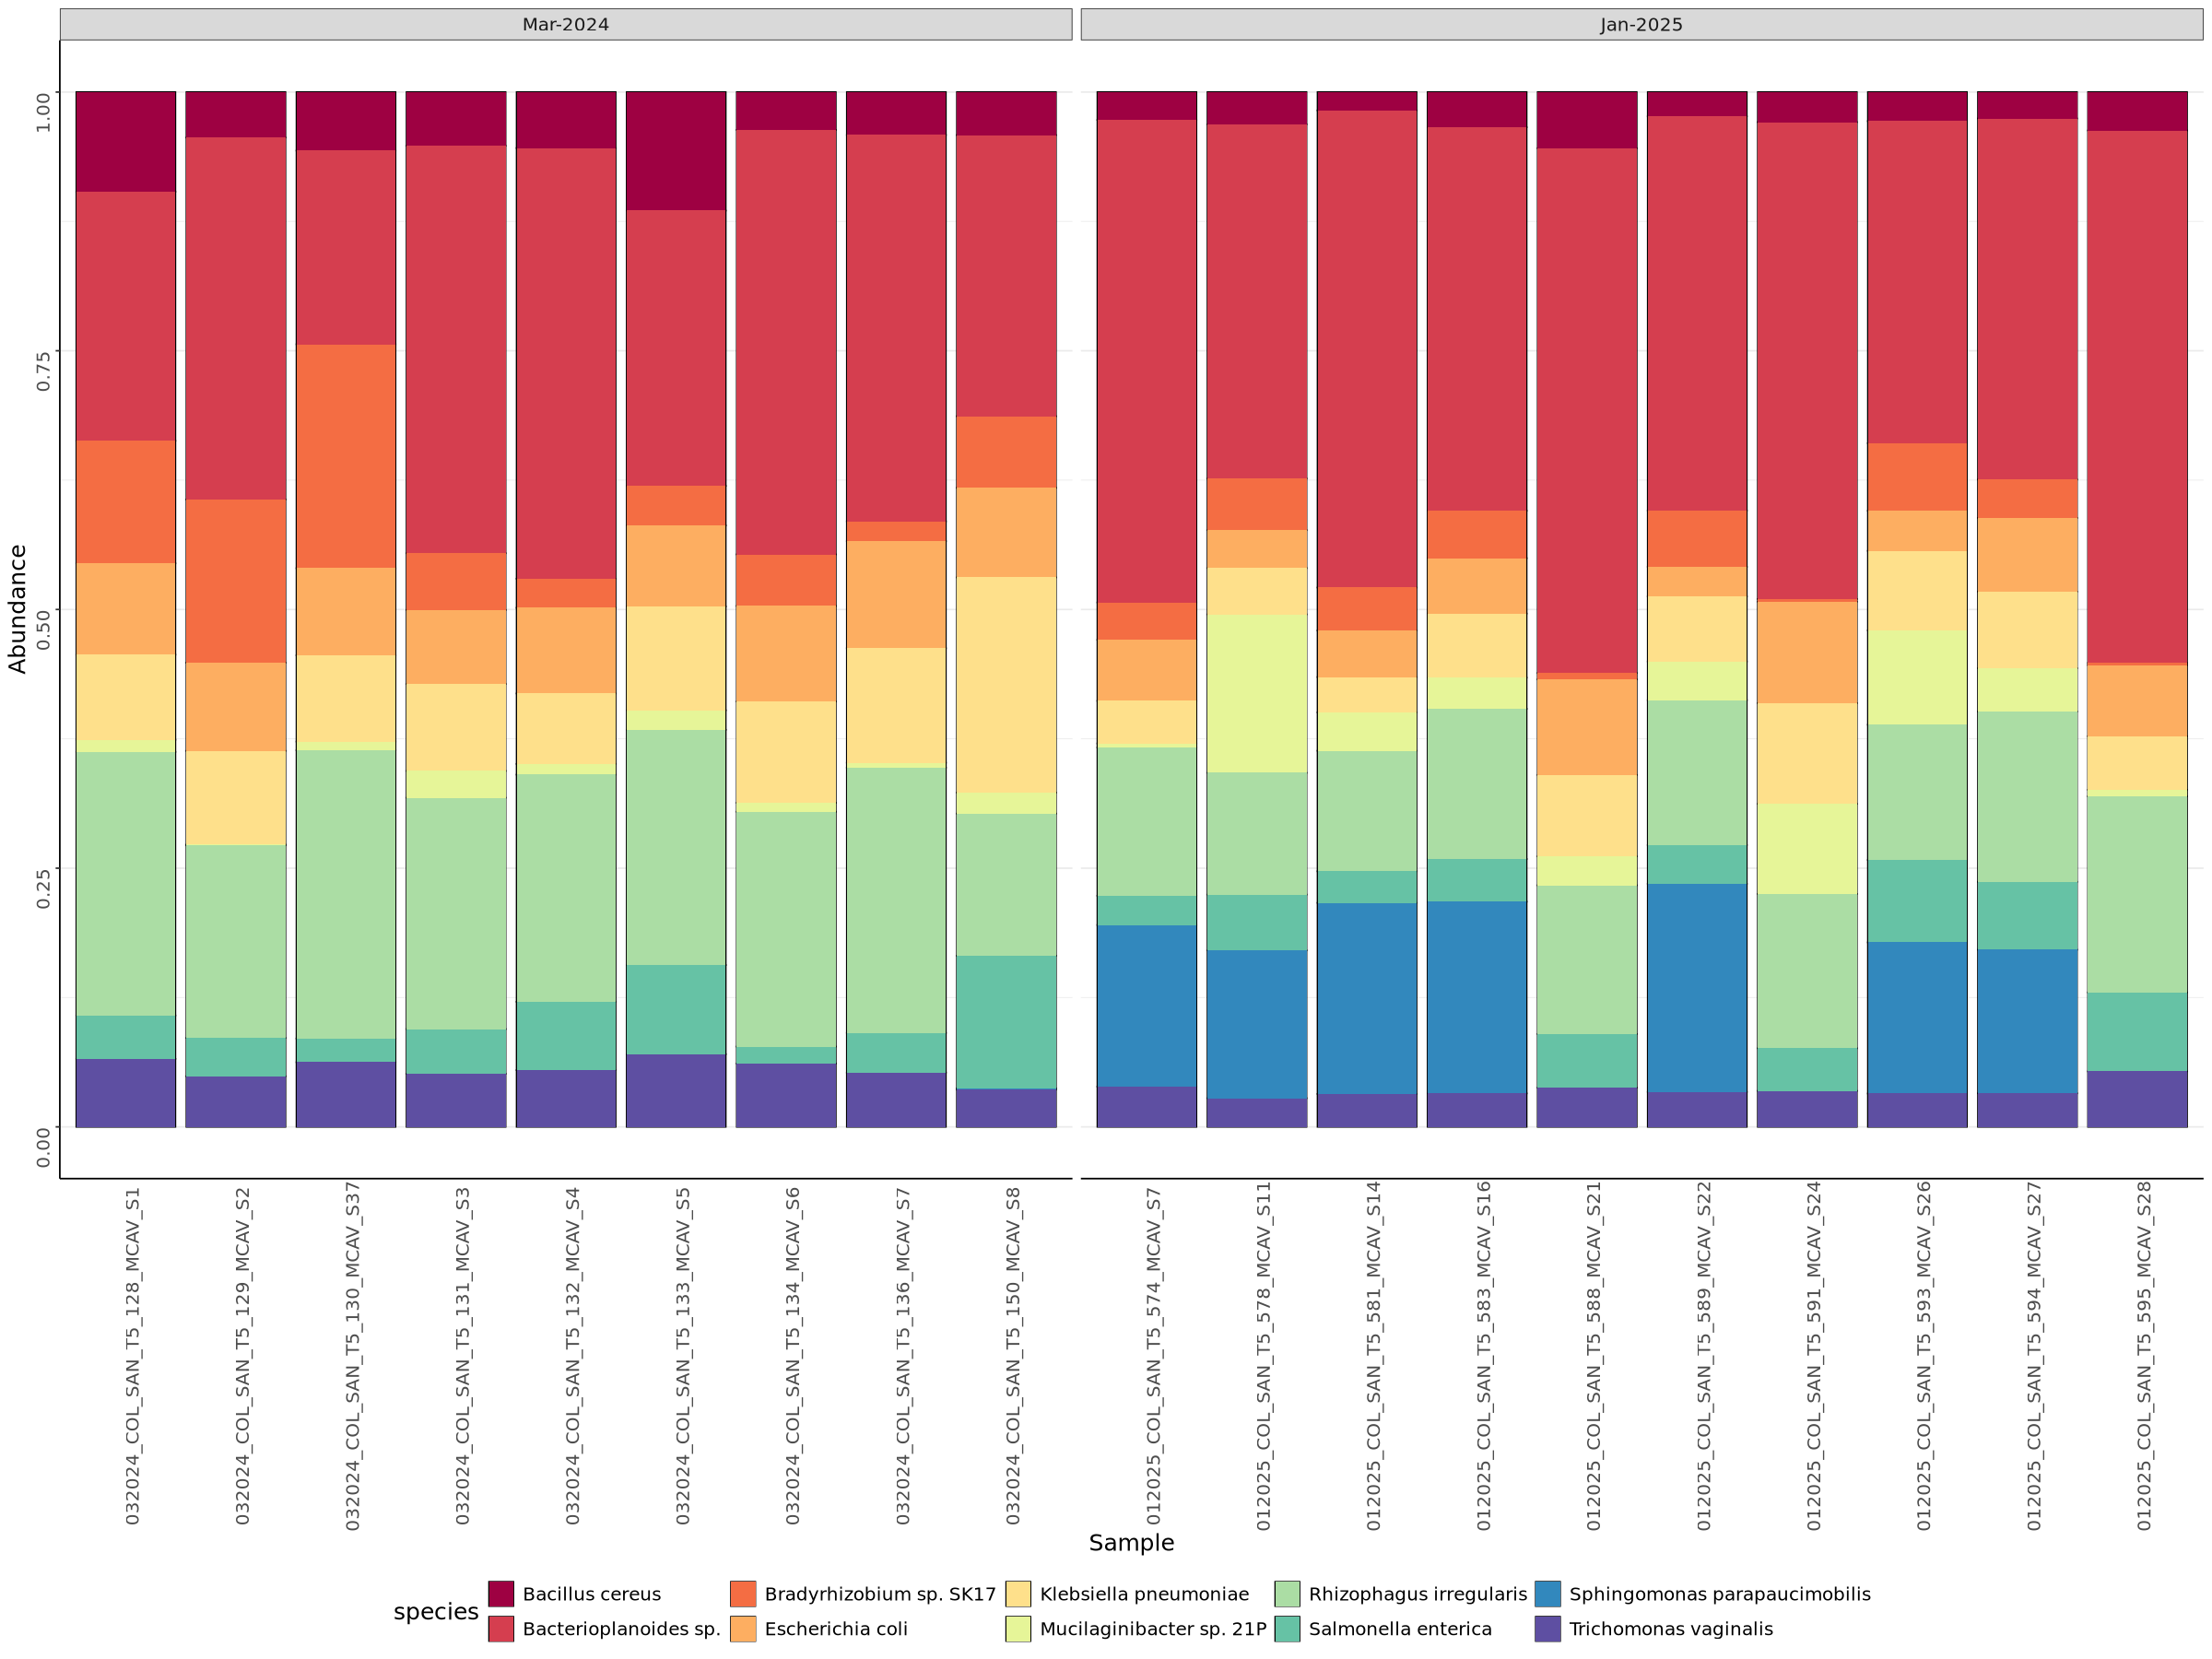

In [141]:
# bar plot of top 10 relative abundances in MCAV samples
mcav_10_rel_bar<-plot_bar(COL_mcav_10_rel,fill='species')+
facet_grid(~Year_m, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack")+
scale_fill_brewer(palette = "Spectral") +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=15))
mcav_10_rel_bar